In [1]:
from utils import *

data_ori = read_json("/data/DFO/data/Llama_3_8B_DFO_data.json")
data_dfo = read_json("/data/DFO/data/iteration_llama_3_DFO_data.json")

In [2]:

def read_dpo_data(data):
    input_text = []
    chosen_text = []
    reject_text = []


    for item in data:
        for conversation in item.get("conversations", []):
            input_text.append(conversation.get("value", ""))
        chosen_value = item.get("chosen", {}).get("value", "")
        reject_value = item.get("rejected", {}).get("value", "")
        
        if chosen_value and reject_value:
            chosen_text.append(chosen_value)
            reject_text.append(reject_value)
    
    return input_text, chosen_text, reject_text



In [3]:
dfo_input_text, dfo_chosen_text, dfo_reject_text = read_dpo_data(data_dfo)
ori_input_text, ori_chosen_text, ori_reject_text = read_dpo_data(data_ori)

# select by input_text  

# # 倒序循环，删除不会影响索引
# for i in range(len(ori_input_text) - 1, -1, -1):
#     if ori_input_text[i] in dfo_input_text:
#         ori_input_text.pop(i)
#         ori_chosen_text.pop(i)
#         ori_reject_text.pop(i)

In [4]:
input_to_data = {text: (chosen, reject) for text, chosen, reject in zip(ori_input_text, ori_chosen_text, ori_reject_text)}

ori_input_text = []
ori_chosen_text = []
ori_reject_text = []

for text in dfo_input_text:
    if text in input_to_data:
        ori_input_text.append(text)
        chosen, reject = input_to_data[text]
        ori_chosen_text.append(chosen)
        ori_reject_text.append(reject)

In [5]:
import Levenshtein

def get_avg_distance(list1, list2):
    if len(list1) != len(list2):
        raise ValueError("Lists must be of the same length")
    
    total_distance = 0
    for str1, str2 in zip(list1, list2):
        total_distance += Levenshtein.distance(str1, str2)
    avg_distance = total_distance / len(list1)
    return avg_distance

print(f"ori dis bewteen chosen and input: {get_avg_distance(ori_chosen_text, ori_input_text)}")
print(f"dfo dis bewteen chosen and input: {get_avg_distance(dfo_chosen_text, dfo_input_text)}")

ori dis bewteen chosen and input: 1123.637630662021
dfo dis bewteen chosen and input: 1060.520184544406


In [6]:
import Levenshtein

def compute_distances(list1, list2):
    distances = []
    for str1, str2 in zip(list1, list2):
        dist = Levenshtein.distance(str1, str2)
        distances.append((str1, str2, dist))
    return distances

# 示例：ori 和 dfo 两组
ori_distances = compute_distances(ori_input_text, ori_chosen_text)
dfo_distances = compute_distances(dfo_input_text, dfo_chosen_text)


In [7]:
def sample_profiles(distances, top_n=5):
    # 排序
    distances_sorted = sorted(distances, key=lambda x: x[2])
    
    # 编辑距离最小的样本
    min_samples = distances_sorted[:top_n]
    
    # 编辑距离最大的样本
    max_samples = distances_sorted[-top_n:]
    
    # 接近平均值的样本
    avg_distance = sum(d[2] for d in distances) / len(distances)
    avg_samples = sorted(distances, key=lambda x: abs(x[2] - avg_distance))[:top_n]
    
    return {
        "min_distance_samples": min_samples,
        "max_distance_samples": max_samples,
        "average_distance_samples": avg_samples,
        "average_distance_value": avg_distance
    }


In [8]:
ori_profile = sample_profiles(ori_distances)
dfo_profile = sample_profiles(dfo_distances)

print("== ori ==")
print("平均编辑距离:", ori_profile["average_distance_value"])
print("最小距离样本:", ori_profile["min_distance_samples"])
print("最大距离样本:", ori_profile["max_distance_samples"])
print("接近平均值样本:", ori_profile["average_distance_samples"])

print("== dfo ==")
print("平均编辑距离:", dfo_profile["average_distance_value"])
print("最小距离样本:", dfo_profile["min_distance_samples"])
print("最大距离样本:", dfo_profile["max_distance_samples"])
print("接近平均值样本:", dfo_profile["average_distance_samples"])


== ori ==
平均编辑距离: 1123.637630662021
最小距离样本: [("Based on the following text:passage 1:1 Preheat oven to 350°F (177°C). Line two large baking sheets2 with silicone baking mats (preferred for ease) or parchment paper.  Prepare pizza dough through step 7, including letting the two balls of dough rest for 15 minutes. Roll out both dough balls onto a lightly floured surface or directly on silicone baking mats.\n\npassage 2:1 Dip the bottom of each roll into cornmeal and place 12 on each baking sheet, cornmeal side down. Sprinkle the tops of the rolls with parmesan cheese.  Bake each batch for 20 minutes or until the sides are lightly browned. Allow to cool for 5 minutes and serve with extra pizza sauce for dipping.\n\npassage 3:To prevent the filling from making your pizza rolls soggy, brush the tops lightly with 1 teaspoon olive oil each. Using your fingers, push dents into the surface of the dough rectangles to prevent bubbling. See photo above for visual. Spread 1/3 cup pizza sauce on top

In [9]:
import matplotlib.pyplot as plt

def compute_distances(list1, list2):
    return [Levenshtein.distance(str1, str2) for str1, str2 in zip(list1, list2)]

def plot_distance_distribution(ori_distances, dfo_distances):
    plt.figure(figsize=(14, 6))

    # 1. 直方图
    plt.subplot(1, 2, 1)
    plt.hist(ori_distances, bins=20, alpha=0.7, label='ORI', density=True)
    plt.hist(dfo_distances, bins=20, alpha=0.7, label='DFO', density=True)
    plt.title('Edit Distance Distribution (Histogram)')
    plt.xlabel('Edit Distance')
    plt.ylabel('Density')
    plt.legend()
    plt.grid(axis='y', linestyle='--', alpha=0.7)

    # 2. 箱型图
    plt.subplot(1, 2, 2)
    plt.boxplot([ori_distances, dfo_distances], labels=['ORI', 'DFO'])
    plt.title('Edit Distance Distribution (Boxplot)')
    plt.ylabel('Edit Distance')

    # 加网格线
    plt.grid(axis='y', linestyle='--', alpha=0.7)

    plt.tight_layout()
    plt.show()

/tmp/ipykernel_3356522/2870631440.py:21: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([ori_distances, dfo_distances], labels=['ORI', 'DFO'])


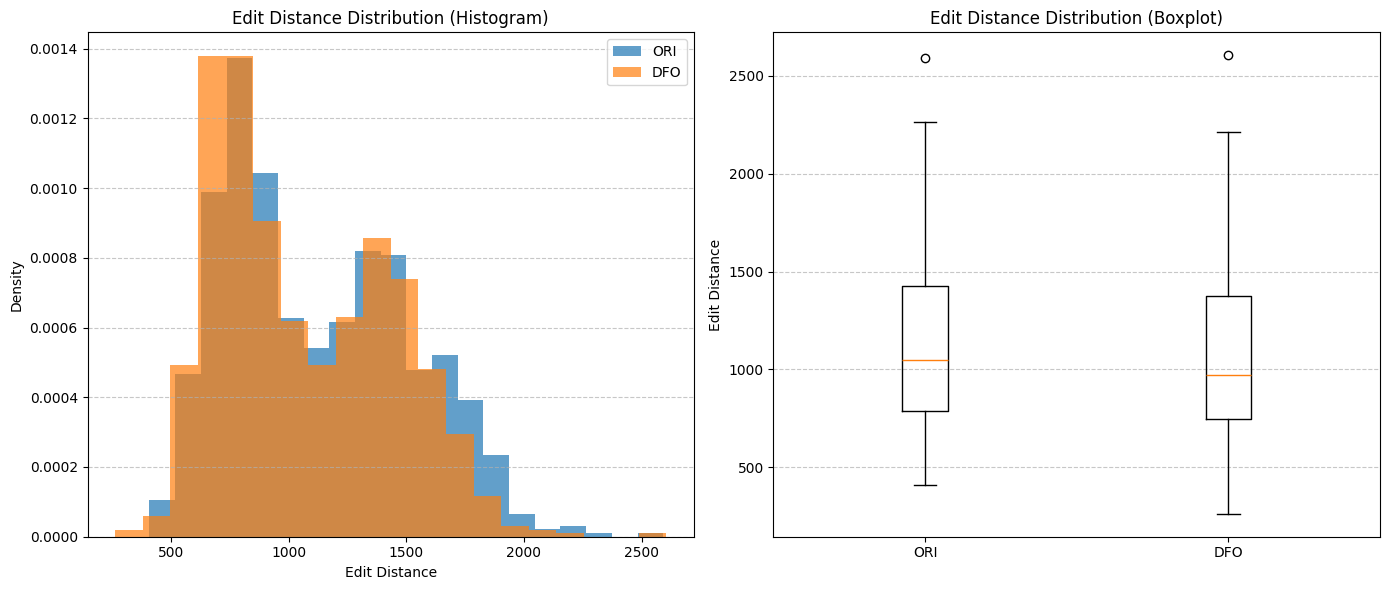

In [10]:
ori_distances = compute_distances(ori_input_text, ori_chosen_text)
dfo_distances = compute_distances(dfo_input_text, dfo_chosen_text)

# 绘图
plot_distance_distribution(ori_distances, dfo_distances)

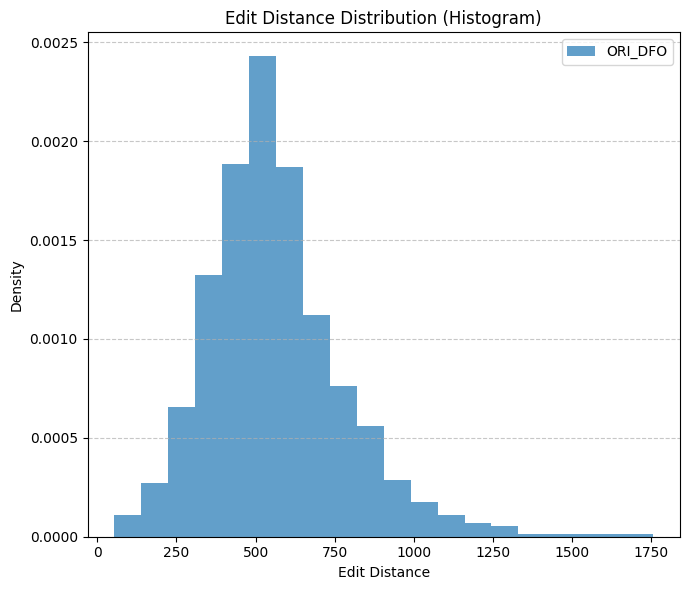

Top 3:
Distance: 54, ORI: Based on the passages, the main differences between Medicare and Medicaid are:

* Medicare applies to everyone who has paid into the system and reached the point of eligibility, while Medicaid is for low-income individuals who could not otherwise afford health insurance.
* Medicare is generally for people who are older or disabled, while Medicaid is for people with limited income and resources.

So, the answer is: Medicare is for people who have paid into the system and are older or disabled, while Medicaid is for low-income individuals., DFO: Based on the passages, the difference between Medicare and Medicaid is:

* Medicare is for people who have paid into the system and reached the point of eligibility, while Medicaid is for low-income individuals who could not otherwise afford health insurance.
* Medicare is generally for people who are older or disabled, while Medicaid is for people with limited income and resources.

So, the answer is: Medicare is for th

In [11]:
ori_dfo_dis = compute_distances(ori_chosen_text, dfo_chosen_text)

# profile
# 1. 直方图
plt.figure(figsize=(7, 6))
plt.hist(ori_dfo_dis, bins=20, alpha=0.7, label='ORI_DFO', density=True)
plt.title('Edit Distance Distribution (Histogram)')
plt.xlabel('Edit Distance')
plt.ylabel('Density')
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


# print top 3 and tail 3 ori_dfo_dis 对应的 ori_chosen_text dfo_chosen_text
def print_top_tail(distances, ori_list, dfo_list, top_n=3):
    sorted_indices = sorted(range(len(distances)), key=lambda i: distances[i])
    
    # 打印最小的 top_n 个
    print("Top 3:")
    for i in sorted_indices[:top_n]:
        print(f"Distance: {distances[i]}, ORI: {ori_list[i]}, DFO: {dfo_list[i]}")
    
    # 打印最大的 top_n 个
    print("\nTail 3:")
    for i in sorted_indices[-top_n:]:
        print(f"Distance: {distances[i]}, ORI: {ori_list[i]}, DFO: {dfo_list[i]}")
print_top_tail(ori_dfo_dis, ori_chosen_text, dfo_chosen_text)


In [12]:
def sample_typical_examples(differences, input_texts, chosen_texts, top_n=5):
    indexed_differences = list(enumerate(differences))

    # 排序：按差值从小到大
    sorted_diffs = sorted(indexed_differences, key=lambda x: x[1])

    # 差值最小的样本
    min_samples = sorted_diffs[:top_n]

    # 差值最大的样本
    max_samples = sorted_diffs[-top_n:]

    # 差值接近平均值的样本
    avg_diff = sum(differences) / len(differences)
    avg_samples = sorted(indexed_differences, key=lambda x: abs(x[1] - avg_diff))[:top_n]

    def extract(samples):
        return [(input_texts[i], chosen_texts[i], diff) for i, diff in samples]

    return {
        "min_difference_samples": extract(min_samples),
        "max_difference_samples": extract(max_samples),
        "average_difference_samples": extract(avg_samples),
        "average_difference_value": avg_diff
    }

In [13]:
distance_differences = [ori - dfo for ori, dfo in zip(ori_distances, dfo_distances)]


# 采样典型样本
samples = sample_typical_examples(distance_differences, dfo_input_text, dfo_chosen_text)

# 打印样本结果
print(f"\n平均差值: {samples['average_difference_value']:.2f}\n")

print("📉 差值最小的样本:")
for input_text, chosen_text, diff in samples['min_difference_samples']:
    print(f"Diff: {diff}, Input: {input_text}, Chosen: {chosen_text}")

print("\n📈 差值最大的样本:")
for input_text, chosen_text, diff in samples['max_difference_samples']:
    print(f"Diff: {diff}, Input: {input_text}, Chosen: {chosen_text}")

print("\n⚖️ 接近平均差值的样本:")
for input_text, chosen_text, diff in samples['average_difference_samples']:
    print(f"Diff: {diff}, Input: {input_text}, Chosen: {chosen_text}")


平均差值: 63.29

📉 差值最小的样本:
Diff: -1240, Input: Based on the following text:passage 1:Hour is the minimum and I won’t go beyond two hours. When it comes time to cook, you can cook it on your grill or sear it in a nice hot cast iron pan (this is what I did). I cooked my steak for 3 1/2 minutes on one side and 3 minutes on the other and it was perfectly done for me.But that might be different in your setting.Using a thermometer and learning to know how the meat “feels” when cooked to your desired temperature is how to learn to cook your perfect steak.our is the minimum and I won’t go beyond two hours. When it comes time to cook, you can cook it on your grill or sear it in a nice hot cast iron pan (this is what I did). I cooked my steak for 3 1/2 minutes on one side and 3 minutes on the other and it was perfectly done for me.

passage 2:A Well Done steak is the hardest to cook. The secret is to do it low and slow. It's the only way to prevent burning while fully cooking it through the middle

In [14]:
import difflib

def highlight_diff(a, b):
    """
    高亮两个字符串的不同部分，返回带颜色的字符串。
    """
    matcher = difflib.SequenceMatcher(None, a, b)
    result_a = []
    result_b = []

    for tag, i1, i2, j1, j2 in matcher.get_opcodes():
        if tag == 'equal':
            result_a.append(a[i1:i2])
            result_b.append(b[j1:j2])
        elif tag == 'replace' or tag == 'delete':
            result_a.append(f'\033[91m{a[i1:i2]}\033[0m')  # 红色
            result_b.append(f'\033[91m{b[j1:j2]}\033[0m')  # 红色
        elif tag == 'insert':
            result_b.append(f'\033[91m{b[j1:j2]}\033[0m')  # 红色
    return ''.join(result_a), ''.join(result_b)

print("\n📈 差值最大的样本（高亮差异部分）:")
for input_text, chosen_text, diff in samples['max_difference_samples']:
    highlighted_input, highlighted_chosen = highlight_diff(input_text, chosen_text)
    print(f"\nDiff: {diff}")
    print(f"Input : {highlighted_input}")
    print(f"Chosen: {highlighted_chosen}")



📈 差值最大的样本（高亮差异部分）:

Diff: 1271
Input : Based on the following text:passage 1:Cooking Procedures 1  : In a large pan, heat oil. Fry the potatoes and carrots until color turns light brown. Remove and set aside. 2  Add beef to the pan; stir-fry for a few minutes until lightly brown. Remove and set aside.  In the same pan, sauté the garlic and onions until translucent. Add chili flakes.

passage 2:1 Bring to a boil then simmer, about an hour or until meat tender.  Add potatoes, carrots and green olives; simmer for another 6 to 8 minutes. Season salt and pepper to taste. Add bell peppers, cook for additional 2 minutes.

passage 3:1 Return beef and accumulated juices to pan. Stir-fry for a few minutes. Add water, tomato sauce, liver spread and bay leaf; stir to combine. Bring to a boil then simmer, about an hour or until meat tender.  Add potatoes, carrots and green olives; simmer for another 6 to 8 minutes.


Answer the following question: how to cook beef caldereta filipino style
If you a

# Eval with Ragas

In [16]:
import nltk
tokenizer = nltk.data.load('nltk:tokenizers/punkt/english.pickle')

def sentencize(text):
    assert '\n21. ' not in text
    ori_text = text 
    for i in range(1, 20): # assume there are at most 10 sentences
        text = text.replace(f"\n{i}. ", f"\n{i}_PLACEHOLDER_") # * \n to fix bug "in 1937.The" can not be split
        text = text.replace(f"\n {i}. ", f"\n {i}_PLACEHOLDER_")

    sentences = [tokenizer.tokenize(text)][0]

    for i in range(1, 11):
        sentences = [sentence.replace(f"{i}_PLACEHOLDER_", f"{i}. ") for sentence in sentences]

    # assert 分割后，所有句子都还能在text中找到
    for s in sentences:
        if s not in ori_text:
            assert False, f"SENTENCIZE ERROR: {s} not in {ori_text}"
    return sentences


In [17]:


from transformers import AutoModelForSequenceClassification

model = AutoModelForSequenceClassification.from_pretrained(
    '/home/XiaqiangTang/.cache/hallucination_evaluation_model', trust_remote_code=True)


/home/XiaqiangTang/miniconda3/envs/sft2/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
You are using a model of type HHEMv2Config to instantiate a model of type HHEMv2. This is not supported for all configurations of models and can yield errors.


In [19]:
import itertools as it
import pandas as pd
ori_pairs, dfo_pairs = [], []
ori_sents_all, dfo_sents_all = [], []   # 暂存每个 input 的句子列表，后面对齐用
for raw, ori, dfo in it.islice(zip(ori_input_text, ori_chosen_text, dfo_chosen_text), 10):
    ori_sents = sentencize(ori)
    dfo_sents = sentencize(dfo)
    ori_sents_all.append(ori_sents)
    dfo_sents_all.append(dfo_sents)

    # 单独收集两种句子对，保持与后面评分结果的一一对应
    ori_pairs.extend([(raw, s) for s in ori_sents])
    dfo_pairs.extend([(raw, s) for s in dfo_sents])

# 3. 评分
ori_scores = model.predict(ori_pairs)   # 长度 == len(ori_pairs)
dfo_scores = model.predict(dfo_pairs)   # 长度 == len(dfo_pairs)

# 4. 整理成 DataFrame（左右并排、不等长补空）
rows, ori_ptr, dfo_ptr = [], 0, 0
for raw, ori_sents, dfo_sents in zip(ori_input_text[:10], ori_sents_all, dfo_sents_all):
    max_len = max(len(ori_sents), len(dfo_sents))
    for i in range(max_len):
        rows.append({
            "input": raw if i == 0 else "",
            "ori_sentence": ori_sents[i] if i < len(ori_sents) else "",
            "ori_score":   float(ori_scores[ori_ptr]) if i < len(ori_sents) else "",
            "dfo_sentence": dfo_sents[i] if i < len(dfo_sents) else "",
            "dfo_score":   float(dfo_scores[dfo_ptr]) if i < len(dfo_sents) else ""
        })
        if i < len(ori_sents): ori_ptr += 1
        if i < len(dfo_sents): dfo_ptr += 1

df = pd.DataFrame(rows)

# 5. 可视化 / 输出
# 若在 Jupyter：df.style.background_gradient(vmax=1, axis=None)
print(df)

                                                input  \
0   Based on the following text:passage 1:1 Take s...   
1   Based on the following text:passage 1:Remember...   
2                                                       
3                                                       
4                                                       
5                                                       
6                                                       
7                                                       
8   Based on the following text:passage 1:In Brita...   
9                                                       
10                                                      
11                                                      
12                                                      
13  Based on the following text:passage 1:Gelish S...   
14                                                      
15                                                      
16                             

# Lambda vs Chosen Probs

In [37]:
# read /data/DFO/logs/prob.txt into a string
import pandas as pd
import re

# Read raw data from file
with open('/data/DFO/logs/prob.txt', 'r') as file:
    raw_data = file.read()

# Split the data into blocks
blocks = raw_data.strip().split('-----------------------------------')

# Extract data
data = []
for block in blocks:
    chosen_match = re.search(r'average_chosen_prob: ([\d.]+)', block)
    reject_match = re.search(r'average_reject_prob: ([\d.]+)', block)
    lambda_match = re.search(r'lambda([\d.]+)', block)
    beta_match = re.search(r'beta([\d.]+)', block)  # optional

    if chosen_match and reject_match and lambda_match:
        data.append({
            'average_chosen_prob': float(chosen_match.group(1)),
            'average_reject_prob': float(reject_match.group(1)),
            'lambda': float(lambda_match.group(1)),
            'beta': float(beta_match.group(1)) if beta_match else None
        })

# Load into DataFrame
df = pd.DataFrame(data)
print(df)




    average_chosen_prob  average_reject_prob  lambda  beta
0              0.845114             0.570325     0.6   NaN
1              0.838246             0.580549     0.8   NaN
2              0.835814             0.585594     0.9   NaN
3              0.824703             0.587095     1.1   NaN
4              0.828232             0.586867     1.2   NaN
5              0.827680             0.587469     1.3   NaN
6              0.827431             0.590960     1.0   NaN
7              0.839481             0.577376     0.7   NaN
8              0.830388             0.591216     1.4   NaN
9              0.827559             0.588945     1.5   NaN
10             0.846697             0.636865     1.0   0.3
11             0.844470             0.638462     1.0   0.4
12             0.847345             0.646206     1.0   0.6
13             0.848414             0.650712     1.0   0.7
14             0.848207             0.654327     1.0   0.8
15             0.848026             0.645768     1.0   0

In [9]:
# 计算 average_chosen_prob 和 lambda 的相关系数
correlation = df['average_chosen_prob'].corr(df['lambda'])
print(f"Correlation between average_chosen_prob and lambda: {correlation:.4f}")

correlation_beta = df['average_chosen_prob'].corr(df['beta'])
print(f"Correlation between average_chosen_prob and beta: {correlation_beta:.4f}")


reject_correlation = df['average_reject_prob'].corr(df['lambda'])
print(f"Correlation between average_reject_prob and lambda: {reject_correlation:.4f}")
reject_correlation_beta = df['average_reject_prob'].corr(df['beta'])
print(f"Correlation between average_reject_prob and beta: {reject_correlation_beta:.4f}")


# format correlation as a table
correlation_df = pd.DataFrame({
    'Metric': ['average_chosen_prob', 'average_reject_prob'],
    'lambda': [correlation, reject_correlation],
    'beta': [correlation_beta, reject_correlation_beta]
})
print(correlation_df)


Correlation between average_chosen_prob and lambda: -0.5206
Correlation between average_chosen_prob and beta: 0.7478
Correlation between average_reject_prob and lambda: 0.0317
Correlation between average_reject_prob and beta: 0.8741
                Metric    lambda      beta
0  average_chosen_prob -0.520639  0.747752
1  average_reject_prob  0.031677  0.874066


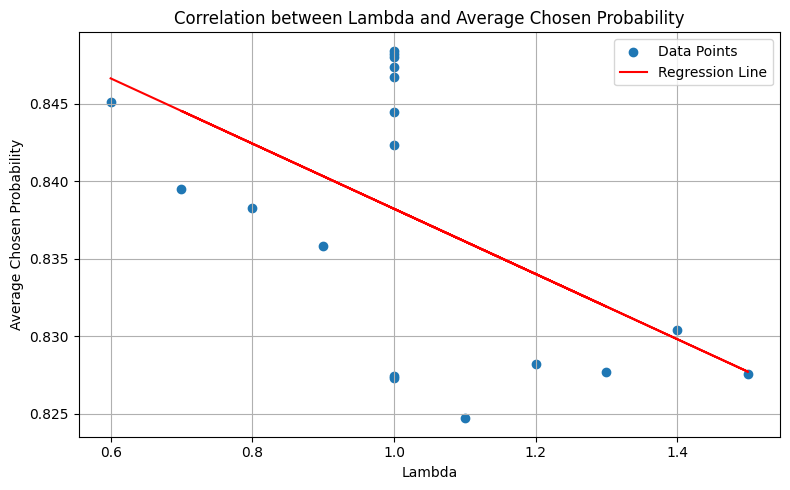

In [4]:
import matplotlib.pyplot as plt
import numpy as np

# 散点图 + 回归线
plt.figure(figsize=(8, 5))
plt.scatter(df['lambda'], df['average_chosen_prob'], label='Data Points')

# 拟合回归线
slope, intercept = np.polyfit(df['lambda'], df['average_chosen_prob'], 1)
regression_line = slope * df['lambda'] + intercept
plt.plot(df['lambda'], regression_line, color='red', label='Regression Line')

plt.xlabel('Lambda')
plt.ylabel('Average Chosen Probability')
plt.title('Correlation between Lambda and Average Chosen Probability')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


# Lambda vs Performance

In [38]:
keep = [1, 1.1, 1.2, 1.3, 1.4, 1.5]

result = (
    df[df['lambda'].isin(keep)]                     # ① 先筛掉不需要的 λ
      .sort_values('average_chosen_prob', ascending=False)  # ② 按 average_chosen_prob 降序
      .drop_duplicates(subset='lambda', keep='first')       # ③ 每个 λ 只保留最高的一行
      .sort_values('lambda')                       # ④ 可选：把 λ 排序回升序
      .reset_index(drop=True)                      # ⑤ 可选：重排索引
)

In [39]:
result

,average_chosen_prob,average_reject_prob,lambda,beta
0,0.848414,0.650712,1.0,0.7
1,0.824703,0.587095,1.1,NaN
2,0.828232,0.586867,1.2,NaN
3,0.827680,0.587469,1.3,NaN
4,0.830388,0.591216,1.4,NaN
5,0.827559,0.588945,1.5,NaN


/tmp/ipykernel_2427516/185828972.py:113: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


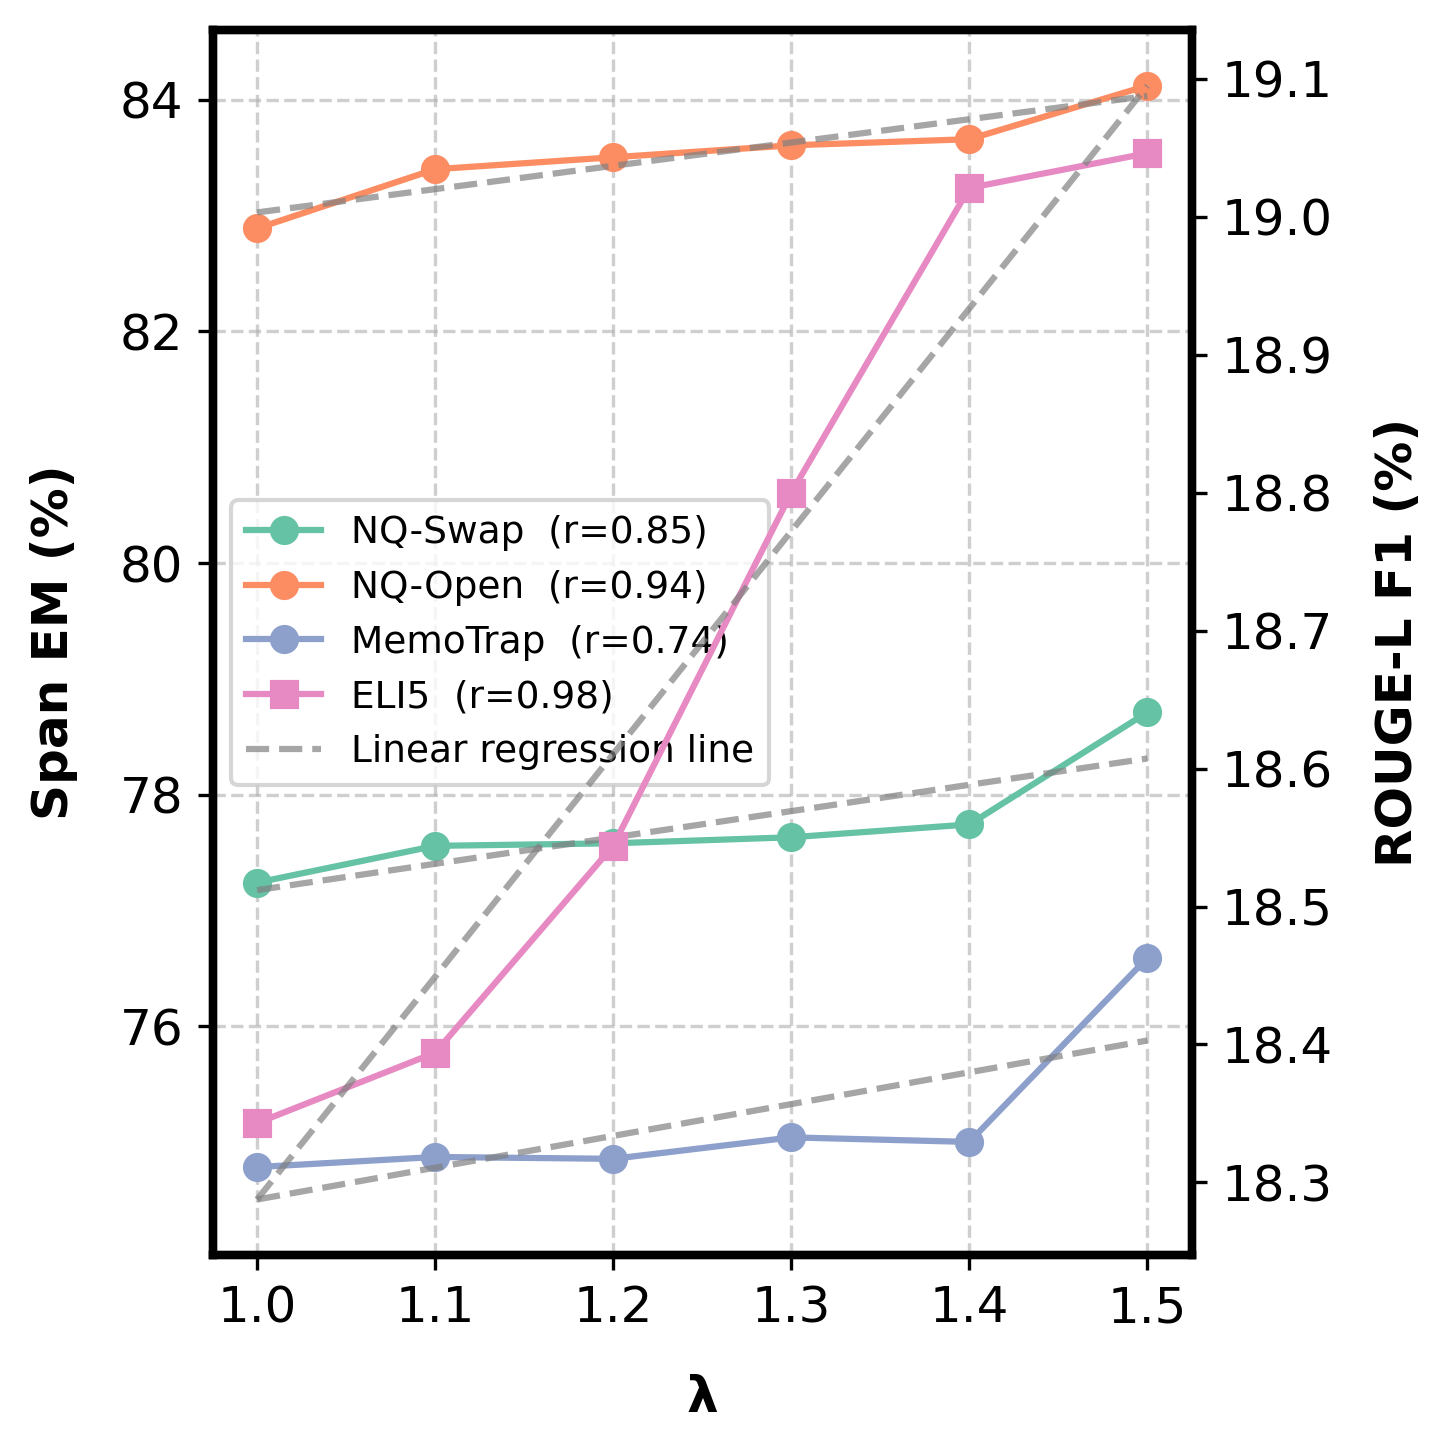

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams.update({
    'font.size': 12,
    'axes.labelsize': 14,
    'axes.titlesize': 14,
    'xtick.labelsize': 12,
    'ytick.labelsize': 12,
    'legend.fontsize': 12,
})


# --------- 读数据 ---------
file_path = "data/log_analysis_report.xlsx"
df = pd.read_excel(file_path, sheet_name="Sheet1")

# --------- 计算均值 & 相关系数 ---------
grouped  = df.groupby("lambda")[["nqswap", "nqopen", "memo-trap", "eli5"]].mean().reset_index()
lambdas  = grouped["lambda"]
metrics  = ["nqswap", "nqopen", "memo-trap", "eli5"]
corr     = {m: np.corrcoef(lambdas, grouped[m])[0, 1] for m in metrics}

# --------- 专业命名 & 配色 ---------
label_map = {
    "nqswap":    "NQ-Swap",
    "nqopen":    "NQ-Open",
    "memo-trap": "MemoTrap",
    "eli5":      "ELI5"
}

color_map = {
    "nqswap":    "#66c2a5",
    "nqopen":    "#fc8d62",
    "memo-trap": "#8da0cb",
    "eli5":      "#e78ac3"
}

# --------- 画图 ---------
fig, ax1 = plt.subplots(figsize=(5, 5), dpi=300, constrained_layout=True)

# —— Span-EM 轴 —— #
first_fit_line = True
for col in ["nqswap", "nqopen", "memo-trap"]:
    y = grouped[col]
    c = color_map[col]

    # 数据曲线
    ax1.plot(lambdas, y, marker="o", linestyle="-", color=c,
             label=f"{label_map[col]}  (r={corr[col]:.2f})")

    # 线性拟合
    coef = np.polyfit(lambdas, y, 1)
    if first_fit_line:
        ax1.plot(lambdas, np.polyval(coef, lambdas), linestyle="--",
                 color="gray", alpha=0.7, label="Linear regression line")
        first_fit_line = False
    else:
        ax1.plot(lambdas, np.polyval(coef, lambdas), linestyle="--",
                 color="gray", alpha=0.7)




ax1.set_xlabel(r"$\mathbf{\lambda}$", fontsize=12, labelpad=10, fontweight='bold')
ax1.set_ylabel("Span EM (%)", fontsize=12, labelpad=10, fontweight='bold')
ax1.grid(True)

# —— ROUGE 轴 —— #
ax2 = ax1.twinx()
y_eli5 = grouped["eli5"]
c = color_map["eli5"]

line_eli5, = ax2.plot(lambdas, y_eli5, marker="s", linestyle="-", color=c,
                      label=f"{label_map['eli5']}  (r={corr['eli5']:.2f})")

coef = np.polyfit(lambdas, y_eli5, 1)
ax2.plot(lambdas, np.polyval(coef, lambdas), linestyle="--",
         color="gray", alpha=0.7)

ax2.set_ylabel("ROUGE-L F1 (%)", fontsize=12, labelpad=10, fontweight='bold')

# —— 图例设置：拆成两个 —— #
h1, l1 = ax1.get_legend_handles_labels()
h2, l2 = ax2.get_legend_handles_labels()

handles = h1 + h2
labels  = l1 + l2
# 将 "Linear Fit" 移到最后
linear_fit_index = labels.index("Linear regression line")
# 弹出 Linear Fit 项
linear_fit_handle = handles.pop(linear_fit_index)
linear_fit_label  = labels.pop(linear_fit_index)
# 添加到末尾
handles.append(linear_fit_handle)
labels.append(linear_fit_label)

ax1.legend(handles, labels, fontsize=9, title_fontsize=10)

# —— 美化 —— #
for spine in ax1.spines.values():
    spine.set_linewidth(2)

for spine in ax2.spines.values():
    spine.set_linewidth(2)

ax1.yaxis.grid(True, linestyle='--', alpha=0.6)
ax1.xaxis.grid(True, linestyle='--', alpha=0.6)
ax2.yaxis.grid(False)

# plt.title(r"Impact of $\lambda$ on QA Performance", fontsize=14)
plt.tight_layout()
plt.show()


# Distribution作图

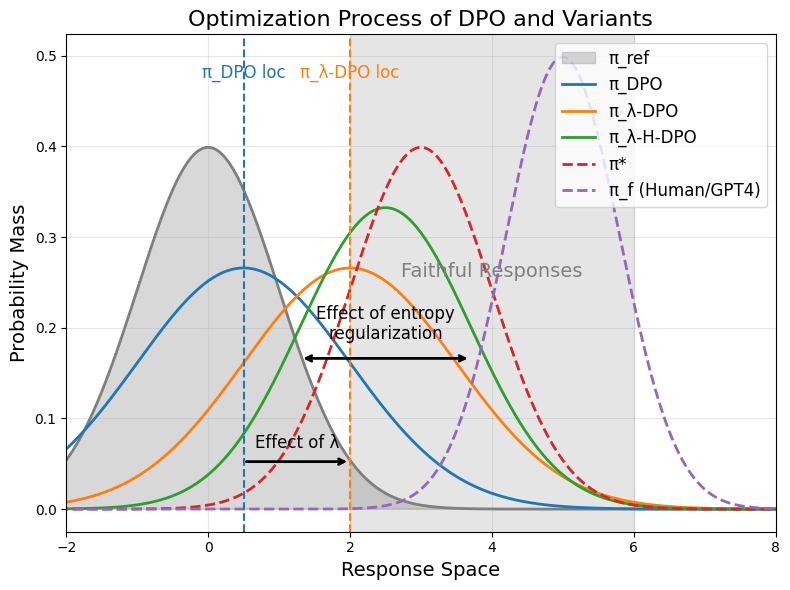

In [26]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

# 设置 x 轴范围
x = np.linspace(-3, 10, 1000)

# 定义各个分布及对应颜色和线型
dists = [
    ("π_ref",     norm(loc=0,   scale=1),   '#7f7f7f', 'fill'),  # 参考模型，灰色填充并加轮廓
    ("π_DPO",     norm(loc=0.5, scale=1.5), '#1f77b4', '-'),
    ("π_λ-DPO",   norm(loc=2,   scale=1.5), '#ff7f0e', '-'),
    ("π_λ-H-DPO", norm(loc=2.5, scale=1.2), '#2ca02c', '-'),
    ("π*",        norm(loc=3,   scale=1),   '#d62728', '--'),
    ("π_f (Human/GPT4)", norm(loc=5, scale=0.8), '#9467bd', '--')
]

plt.figure(figsize=(8, 6))

# 绘制各分布曲线或填充
for label, dist, color, style in dists:
    y = dist.pdf(x)
    if style == 'fill':
        # 填充
        plt.fill_between(x, y, color=color, alpha=0.3, label=label)
        # 加轮廓线
        plt.plot(x, y, color=color, linestyle='-', linewidth=2)
    else:
        plt.plot(x, y, label=label, color=color, linestyle=style, linewidth=2)

# π_DPO 和 π_λ-DPO 的 loc 虚线，并标注
loc_dpo = 0.5
loc_lambda_dpo = 2
plt.axvline(loc_dpo, linestyle='--', color='#1f77b4', linewidth=1.5)
plt.text(loc_dpo, plt.ylim()[1]*0.9, 'π_DPO loc', ha='center', va='bottom', color='#1f77b4', fontsize=12)
plt.axvline(loc_lambda_dpo, linestyle='--', color='#ff7f0e', linewidth=1.5)
plt.text(loc_lambda_dpo, plt.ylim()[1]*0.9, 'π_λ-DPO loc', ha='center', va='bottom', color='#ff7f0e', fontsize=12)

# Effect of λ 箭头
y_arrow1 = plt.ylim()[1] * 0.1
plt.annotate('', xy=(loc_lambda_dpo, y_arrow1), xytext=(loc_dpo, y_arrow1),
             arrowprops=dict(arrowstyle='->', lw=2, color='black'))
plt.text((loc_dpo + loc_lambda_dpo)/2, y_arrow1 * 1.2, 'Effect of λ',
         ha='center', va='bottom', fontsize=12)

# Effect of entropy regularization 双向箭头
loc_s = 2.5
scale_s = 1.2
start2 = loc_s - scale_s
end2 = loc_s + scale_s
y_arrow2 = norm(loc_s, scale_s).pdf(loc_s) * 0.5
plt.annotate('', xy=(end2, y_arrow2), xytext=(start2, y_arrow2),
             arrowprops=dict(arrowstyle='<->', lw=2, color='black'))
plt.text(loc_s, y_arrow2 * 1.1, 'Effect of entropy\nregularization',
         ha='center', va='bottom', fontsize=12)

# 阴影高亮“Faithful Responses”区域
good_lower, good_upper = 2, 6
plt.axvspan(good_lower, good_upper, color='grey', alpha=0.2)
plt.text((good_lower + good_upper) / 2, plt.ylim()[1] * 0.5, 'Faithful Responses',
         ha='center', va='center', fontsize=14, color='grey')

# 轴范围
plt.xlim(-2, 8)

# 图形美化
plt.xlabel("Response Space", fontsize=14)
plt.ylabel("Probability Mass", fontsize=14)
plt.title("Optimization Process of DPO and Variants", fontsize=16)
plt.grid(alpha=0.3)
plt.legend(fontsize=12, loc='upper right')
plt.tight_layout()
plt.show()


# box plot for LD 

In [27]:
# 单元格 1：导入库
import csv
import json
import os
import pickle
from matplotlib import pyplot as plt
from transformers import AutoTokenizer, AutoModelForCausalLM
import torch
# from vllm import LLM, SamplingParams # vllm 未在代码中使用，注释掉以防出错，如果需要请取消注释
from tqdm import tqdm
import argparse
import seaborn as sns
import numpy as np

In [28]:
# load /data/DFO/data/2-proverb-translation.csv_results.pkl
import pickle
with open("/data/DFO/data/2-proverb-translation.csv_results.pkl", "rb") as f:
    results = pickle.load(f)

    


--- Starting Data Analysis ---
Analyzing 843 samples.

--- 1. Average Probability Change Analysis ---
Average ΔP(t+) [Chosen]:   -0.096033
Average ΔP(t-) [Rejected]: 0.082030
Average Sum(ΔP(other)) per sample: 0.014002 (Expected: ~0.014002)
Average ΔP(z) [Individual Other Token]: 2.549097e-03

--- 2. Hypothesis Testing ---
Could not perform Wilcoxon test for ΔP(t-): object of type 'numpy.float32' has no len()
Test ΔP(t-) < 0: t-statistic=11.5871, p-value (t-test)=1
  >> Result (t-test): Fail to reject H0. No significant evidence that ΔP(t-) < 0 (p >= 0.05).
Test ΔP(t+) > 0: t-statistic=-13.1684, p-value (t-test)=1, p-value (Wilcoxon)=1
  >> Result (t-test): Fail to reject H0. No significant evidence that ΔP(t+) > 0 (p >= 0.05).
Test ΔP(t+) + ΔP(t-) != 0: t-statistic=-2.1340, p-value (t-test)=0.03313, p-value (Wilcoxon)=2.423e-16
  >> Result (t-test): Reject H0. Evidence suggests ΔP(t+) + ΔP(t-) is significantly different from 0 (p < 0.05).
     Mean sum: -0.014002. Indicates probabili

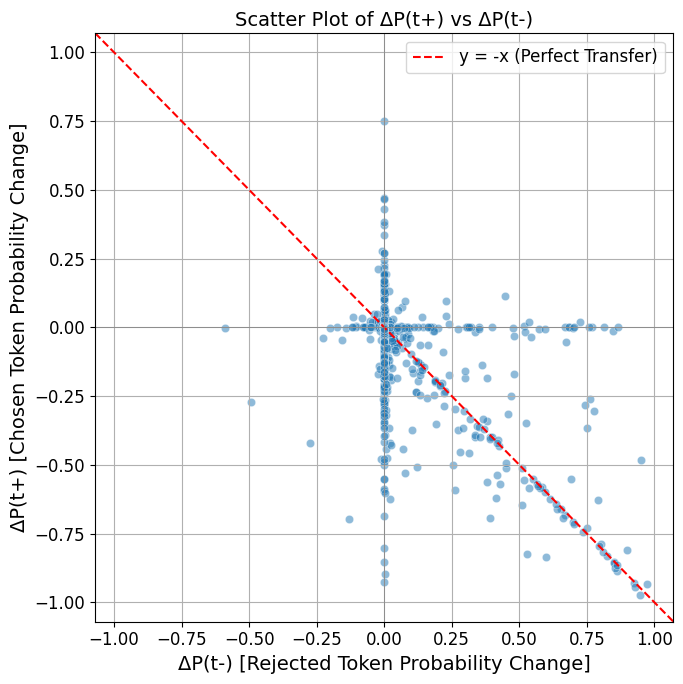


--- 4. Distribution of ΔP for Other Tokens ---
Saved distribution plot to other_token_delta_distribution.png


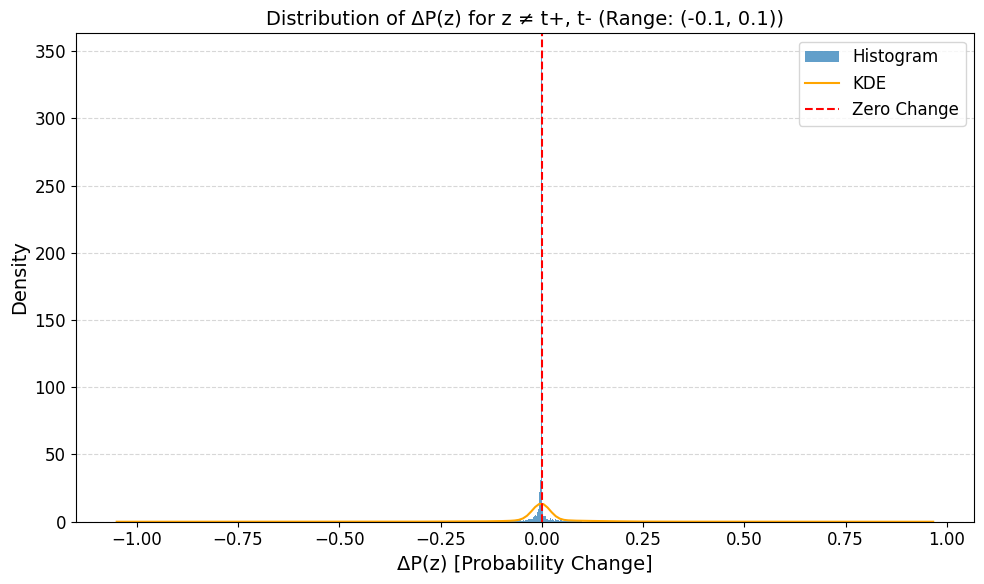

  Mean of individual ΔP(other):   2.549097e-03
  Median of individual ΔP(other): -1.992583e-04
  >> Mean deviates noticeably from zero.

--- Analysis Complete ---


In [29]:
# 单元格 8：数据聚合与分析
from scipy import stats
import numpy as np
import pandas as pd
print("\n--- Starting Data Analysis ---")

delta_p_chosen =  results['delta_chosen_probabilities']
delta_p_rejected = results['delta_reject_probabilities']
delta_p_other_individual = results['delta_chosen_bg_tokens']
# Check if data was collected
if False:
    print("No data collected. Cannot perform analysis. Please run previous cells.")
else:
    # Convert lists to NumPy arrays for efficient computation
    delta_p_chosen_np = delta_p_chosen
    delta_p_rejected_np = delta_p_rejected
    delta_p_other_individual_np = np.array(delta_p_other_individual) # This might be large!

    num_samples = len(delta_p_chosen_np)
    print(f"Analyzing {num_samples} samples.")
    if len(delta_p_rejected_np) != num_samples:
         print(f"Warning: Mismatch in sample counts! Chosen: {num_samples}, Rejected: {len(delta_p_rejected_np)}")
         # Optionally truncate to the minimum length if mismatch occurs
         min_len = min(num_samples, len(delta_p_rejected_np))
         delta_p_chosen_np = delta_p_chosen_np[:min_len]
         delta_p_rejected_np = delta_p_rejected_np[:min_len]
         num_samples = min_len
         print(f"Adjusted sample count to {num_samples}.")


    # 1. 平均变化分析
    print("\n--- 1. Average Probability Change Analysis ---")
    avg_delta_chosen = np.mean(delta_p_chosen_np)
    avg_delta_rejected = np.mean(delta_p_rejected_np)

    # Calculate sum for other tokens per sample: sum_other = -(ΔP(t+) + ΔP(t-))
    delta_p_other_sum_np = -(delta_p_chosen_np + delta_p_rejected_np)
    avg_delta_other_sum = np.mean(delta_p_other_sum_np)

    print(f"Average ΔP(t+) [Chosen]:   {avg_delta_chosen:.6f}")
    print(f"Average ΔP(t-) [Rejected]: {avg_delta_rejected:.6f}")
    print(f"Average Sum(ΔP(other)) per sample: {avg_delta_other_sum:.6f} (Expected: ~{-(avg_delta_chosen + avg_delta_rejected):.6f})")

    # Average change for a single 'other' token (use with caution if list is huge)
    if delta_p_other_individual_np.size > 0:
         avg_delta_other_individual = np.mean(delta_p_other_individual_np)
         print(f"Average ΔP(z) [Individual Other Token]: {avg_delta_other_individual:.6e}") # Use scientific notation if small
    else:
         print("No data for individual other token analysis.")


    # 2. 假设检验
    print("\n--- 2. Hypothesis Testing ---")
    alpha = 0.05 # Significance level

    # Test H0: mean(ΔP(t-)) >= 0 vs H1: mean(ΔP(t-)) < 0
    t_stat_rej, p_val_rej_ttest = stats.ttest_1samp(delta_p_rejected_np, 0, alternative='less')
    # Note: Wilcoxon requires non-zero differences. Add small epsilon or filter zeros if needed.
    try:
        # Filter out exact zeros for Wilcoxon if they cause issues
        non_zero_rejected = delta_p_rejected_np[delta_p_rejected_np != 0]
        if len(non_zero_rejected) > 0:
             _, p_val_rej_wilcoxon = stats.wilcoxon(non_zero_rejected, alternative='less')
             print(f"Test ΔP(t-) < 0: t-statistic={t_stat_rej:.4f}, p-value (t-test)={p_val_rej_ttest:.4g}, p-value (Wilcoxon)={p_val_rej_wilcoxon:.4g}")
        else:
            print(f"Test ΔP(t-) < 0: t-statistic={t_stat_rej:.4f}, p-value (t-test)={p_val_rej_ttest:.4g} (Wilcoxon skipped: no non-zero values)")

        if p_val_rej_ttest < alpha:
             print(f"  >> Result (t-test): Reject H0. Evidence suggests ΔP(t-) is significantly less than 0 (p < {alpha}).")
        else:
             print(f"  >> Result (t-test): Fail to reject H0. No significant evidence that ΔP(t-) < 0 (p >= {alpha}).")

    except Exception as e:
        print(f"Could not perform Wilcoxon test for ΔP(t-): {e}")
        print(f"Test ΔP(t-) < 0: t-statistic={t_stat_rej:.4f}, p-value (t-test)={p_val_rej_ttest:.4g}")
        # Repeat t-test result reporting
        if p_val_rej_ttest < alpha:
             print(f"  >> Result (t-test): Reject H0. Evidence suggests ΔP(t-) is significantly less than 0 (p < {alpha}).")
        else:
             print(f"  >> Result (t-test): Fail to reject H0. No significant evidence that ΔP(t-) < 0 (p >= {alpha}).")


    # Test H0: mean(ΔP(t+)) <= 0 vs H1: mean(ΔP(t+)) > 0
    t_stat_cho, p_val_cho_ttest = stats.ttest_1samp(delta_p_chosen_np, 0, alternative='greater')
    try:
         non_zero_chosen = delta_p_chosen_np[delta_p_chosen_np != 0]
         if len(non_zero_chosen) > 0:
            _, p_val_cho_wilcoxon = stats.wilcoxon(non_zero_chosen, alternative='greater')
            print(f"Test ΔP(t+) > 0: t-statistic={t_stat_cho:.4f}, p-value (t-test)={p_val_cho_ttest:.4g}, p-value (Wilcoxon)={p_val_cho_wilcoxon:.4g}")
         else:
             print(f"Test ΔP(t+) > 0: t-statistic={t_stat_cho:.4f}, p-value (t-test)={p_val_cho_ttest:.4g} (Wilcoxon skipped: no non-zero values)")

         if p_val_cho_ttest < alpha:
             print(f"  >> Result (t-test): Reject H0. Evidence suggests ΔP(t+) is significantly greater than 0 (p < {alpha}).")
         else:
             print(f"  >> Result (t-test): Fail to reject H0. No significant evidence that ΔP(t+) > 0 (p >= {alpha}).")
    except Exception as e:
        print(f"Could not perform Wilcoxon test for ΔP(t+): {e}")
        print(f"Test ΔP(t+) > 0: t-statistic={t_stat_cho:.4f}, p-value (t-test)={p_val_cho_ttest:.4g}")
        # Repeat t-test result reporting
        if p_val_cho_ttest < alpha:
             print(f"  >> Result (t-test): Reject H0. Evidence suggests ΔP(t+) is significantly greater than 0 (p < {alpha}).")
        else:
             print(f"  >> Result (t-test): Fail to reject H0. No significant evidence that ΔP(t+) > 0 (p >= {alpha}).")


    # Test H0: mean(ΔP(t+) + ΔP(t-)) = 0 vs H1: mean(ΔP(t+) + ΔP(t-)) != 0
    prob_sum_per_sample = delta_p_chosen_np + delta_p_rejected_np # Same as -delta_p_other_sum_np
    t_stat_sum, p_val_sum_ttest = stats.ttest_1samp(prob_sum_per_sample, 0) # Two-sided test
    try:
        non_zero_sum = prob_sum_per_sample[prob_sum_per_sample != 0]
        if len(non_zero_sum) > 0:
            _, p_val_sum_wilcoxon = stats.wilcoxon(non_zero_sum) # Two-sided test
            print(f"Test ΔP(t+) + ΔP(t-) != 0: t-statistic={t_stat_sum:.4f}, p-value (t-test)={p_val_sum_ttest:.4g}, p-value (Wilcoxon)={p_val_sum_wilcoxon:.4g}")
        else:
             print(f"Test ΔP(t+) + ΔP(t-) != 0: t-statistic={t_stat_sum:.4f}, p-value (t-test)={p_val_sum_ttest:.4g} (Wilcoxon skipped: no non-zero values)")

        if p_val_sum_ttest < alpha:
            print(f"  >> Result (t-test): Reject H0. Evidence suggests ΔP(t+) + ΔP(t-) is significantly different from 0 (p < {alpha}).")
            print(f"     Mean sum: {np.mean(prob_sum_per_sample):.6f}. Indicates probability is not perfectly conserved between t+ and t-.")
        else:
            print(f"  >> Result (t-test): Fail to reject H0. No significant evidence that ΔP(t+) + ΔP(t-) differs from 0 (p >= {alpha}).")
            print(f"     Mean sum: {np.mean(prob_sum_per_sample):.6f}. Consistent with probability transfer between t+ and t-.")
    except Exception as e:
        print(f"Could not perform Wilcoxon test for sum ΔP(t+) + ΔP(t-): {e}")
        print(f"Test ΔP(t+) + ΔP(t-) != 0: t-statistic={t_stat_sum:.4f}, p-value (t-test)={p_val_sum_ttest:.4g}")
         # Repeat t-test result reporting
        if p_val_sum_ttest < alpha:
            print(f"  >> Result (t-test): Reject H0. Evidence suggests ΔP(t+) + ΔP(t-) is significantly different from 0 (p < {alpha}).")
            print(f"     Mean sum: {np.mean(prob_sum_per_sample):.6f}. Indicates probability is not perfectly conserved between t+ and t-.")
        else:
            print(f"  >> Result (t-test): Fail to reject H0. No significant evidence that ΔP(t+) + ΔP(t-) differs from 0 (p >= {alpha}).")
            print(f"     Mean sum: {np.mean(prob_sum_per_sample):.6f}. Consistent with probability transfer between t+ and t-.")


    # 3. 相关性分析
    print("\n--- 3. Correlation Analysis ---")
    pearson_corr, p_pearson = stats.pearsonr(delta_p_chosen_np, delta_p_rejected_np)
    spearman_corr, p_spearman = stats.spearmanr(delta_p_chosen_np, delta_p_rejected_np)
    print(f"Correlation between ΔP(t+) and ΔP(t-):")
    print(f"  Pearson Coefficient:  {pearson_corr:.4f} (p-value: {p_pearson:.4g})")
    print(f"  Spearman Coefficient: {spearman_corr:.4f} (p-value: {p_spearman:.4g})")
    if pearson_corr < -0.7:
        print("  >> Strong negative correlation observed, consistent with probability transfer hypothesis.")
    elif pearson_corr < -0.4:
        print("  >> Moderate negative correlation observed.")
    else:
        print("  >> Weak or no strong negative correlation observed.")

    # Plot scatter plot for visual inspection
    plt.figure(figsize=(7, 7))
    sns.scatterplot(x=delta_p_rejected_np, y=delta_p_chosen_np, alpha=0.5)
    plt.title('Scatter Plot of ΔP(t+) vs ΔP(t-)')
    plt.xlabel('ΔP(t-) [Rejected Token Probability Change]')
    plt.ylabel('ΔP(t+) [Chosen Token Probability Change]')
    plt.grid(True)
    # Add a y=-x line for reference (perfect transfer)
    lim_min = min(np.min(delta_p_rejected_np), np.min(delta_p_chosen_np)) * 1.1
    lim_max = max(np.max(delta_p_rejected_np), np.max(delta_p_chosen_np)) * 1.1
    plt.plot([lim_min, lim_max], [-lim_min, -lim_max], color='red', linestyle='--', label='y = -x (Perfect Transfer)')
    plt.xlim(lim_min, lim_max)
    plt.ylim(lim_min, lim_max)
    plt.legend()
    plt.axhline(0, color='grey', lw=0.5)
    plt.axvline(0, color='grey', lw=0.5)
    plt.tight_layout()
    plt.savefig("correlation_scatter_plot.png")
    print("Saved scatter plot to correlation_scatter_plot.png")
    plt.show()


    # 4. 检验其他 token 无趋势
    print("\n--- 4. Distribution of ΔP for Other Tokens ---")
    if delta_p_other_individual_np.size > 0:
        plt.figure(figsize=(10, 6))
        # Use a large number of bins, but check data range first
        data_min, data_max = np.min(delta_p_other_individual_np), np.max(delta_p_other_individual_np)
        # Focus the histogram range slightly around zero if the tails are very long
        hist_range = (-0.1, 0.1) # Adjust this range based on expected/observed values
        num_bins = 200

        plt.hist(delta_p_other_individual_np, bins=num_bins, range=hist_range, density=True, alpha=0.7, label='Histogram')
        # Overlay KDE plot for smoother distribution view
        sns.kdeplot(delta_p_other_individual_np, color='orange', label='KDE', warn_singular=False) # warn_singular=False handles cases with identical values

        plt.title(f'Distribution of ΔP(z) for z ≠ t+, t- (Range: {hist_range})')
        plt.xlabel('ΔP(z) [Probability Change]')
        plt.ylabel('Density')
        plt.axvline(0, color='red', linestyle='--', label='Zero Change')
        plt.legend()
        plt.grid(True, axis='y', linestyle='--', alpha=0.5)
        plt.tight_layout()
        plt.savefig("other_token_delta_distribution.png")
        print("Saved distribution plot to other_token_delta_distribution.png")
        plt.show()

        # Quantitative check: mean and median of other deltas
        mean_other_indiv = np.mean(delta_p_other_individual_np)
        median_other_indiv = np.median(delta_p_other_individual_np)
        print(f"  Mean of individual ΔP(other):   {mean_other_indiv:.6e}")
        print(f"  Median of individual ΔP(other): {median_other_indiv:.6e}")
        if abs(mean_other_indiv) < 1e-4: # Check if mean is close to zero
            print("  >> Mean is close to zero, suggesting no strong systematic shift for other tokens overall.")
        else:
            print("  >> Mean deviates noticeably from zero.")

    else:                                                                                                                                                                       
        print("No data collected for individual other tokens.")

print("\n--- Analysis Complete ---")

In [30]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
from scipy.stats import pearsonr
import seaborn as sns

# 计算均值（示例中假设 delta_p_*_np 已经定义）
mean_delta_p_chosen_np = -np.mean(delta_p_chosen_np)
mean_delta_p_rejected_np = -np.mean(delta_p_rejected_np)
mean_delta_p_other_individual_np = np.mean(delta_p_other_individual_np)

labels = [
    r'$\mathbf{z_c}$' ,#+ '\n(Chosen)',
    r'$\mathbf{z_p}$',# + '\n(Rejected)',
    r'$\mathbf{z_{other}}$' ,#+ '\n(Others)'
][::-1]
means = [mean_delta_p_chosen_np, mean_delta_p_rejected_np, mean_delta_p_other_individual_np][::-1]

palette = sns.color_palette("muted")[0:3][::-1]


# 计算相关系数
r_cr, _ = pearsonr(delta_p_chosen_np, delta_p_rejected_np)
# 随机下采样 other 个数以匹配长度
if len(delta_p_other_individual_np) > len(delta_p_chosen_np):
    delta_p_other_individual_np = np.random.choice(delta_p_other_individual_np,
                                                   len(delta_p_chosen_np),
                                                   replace=False)
r_co, _ = pearsonr(delta_p_chosen_np, delta_p_other_individual_np)




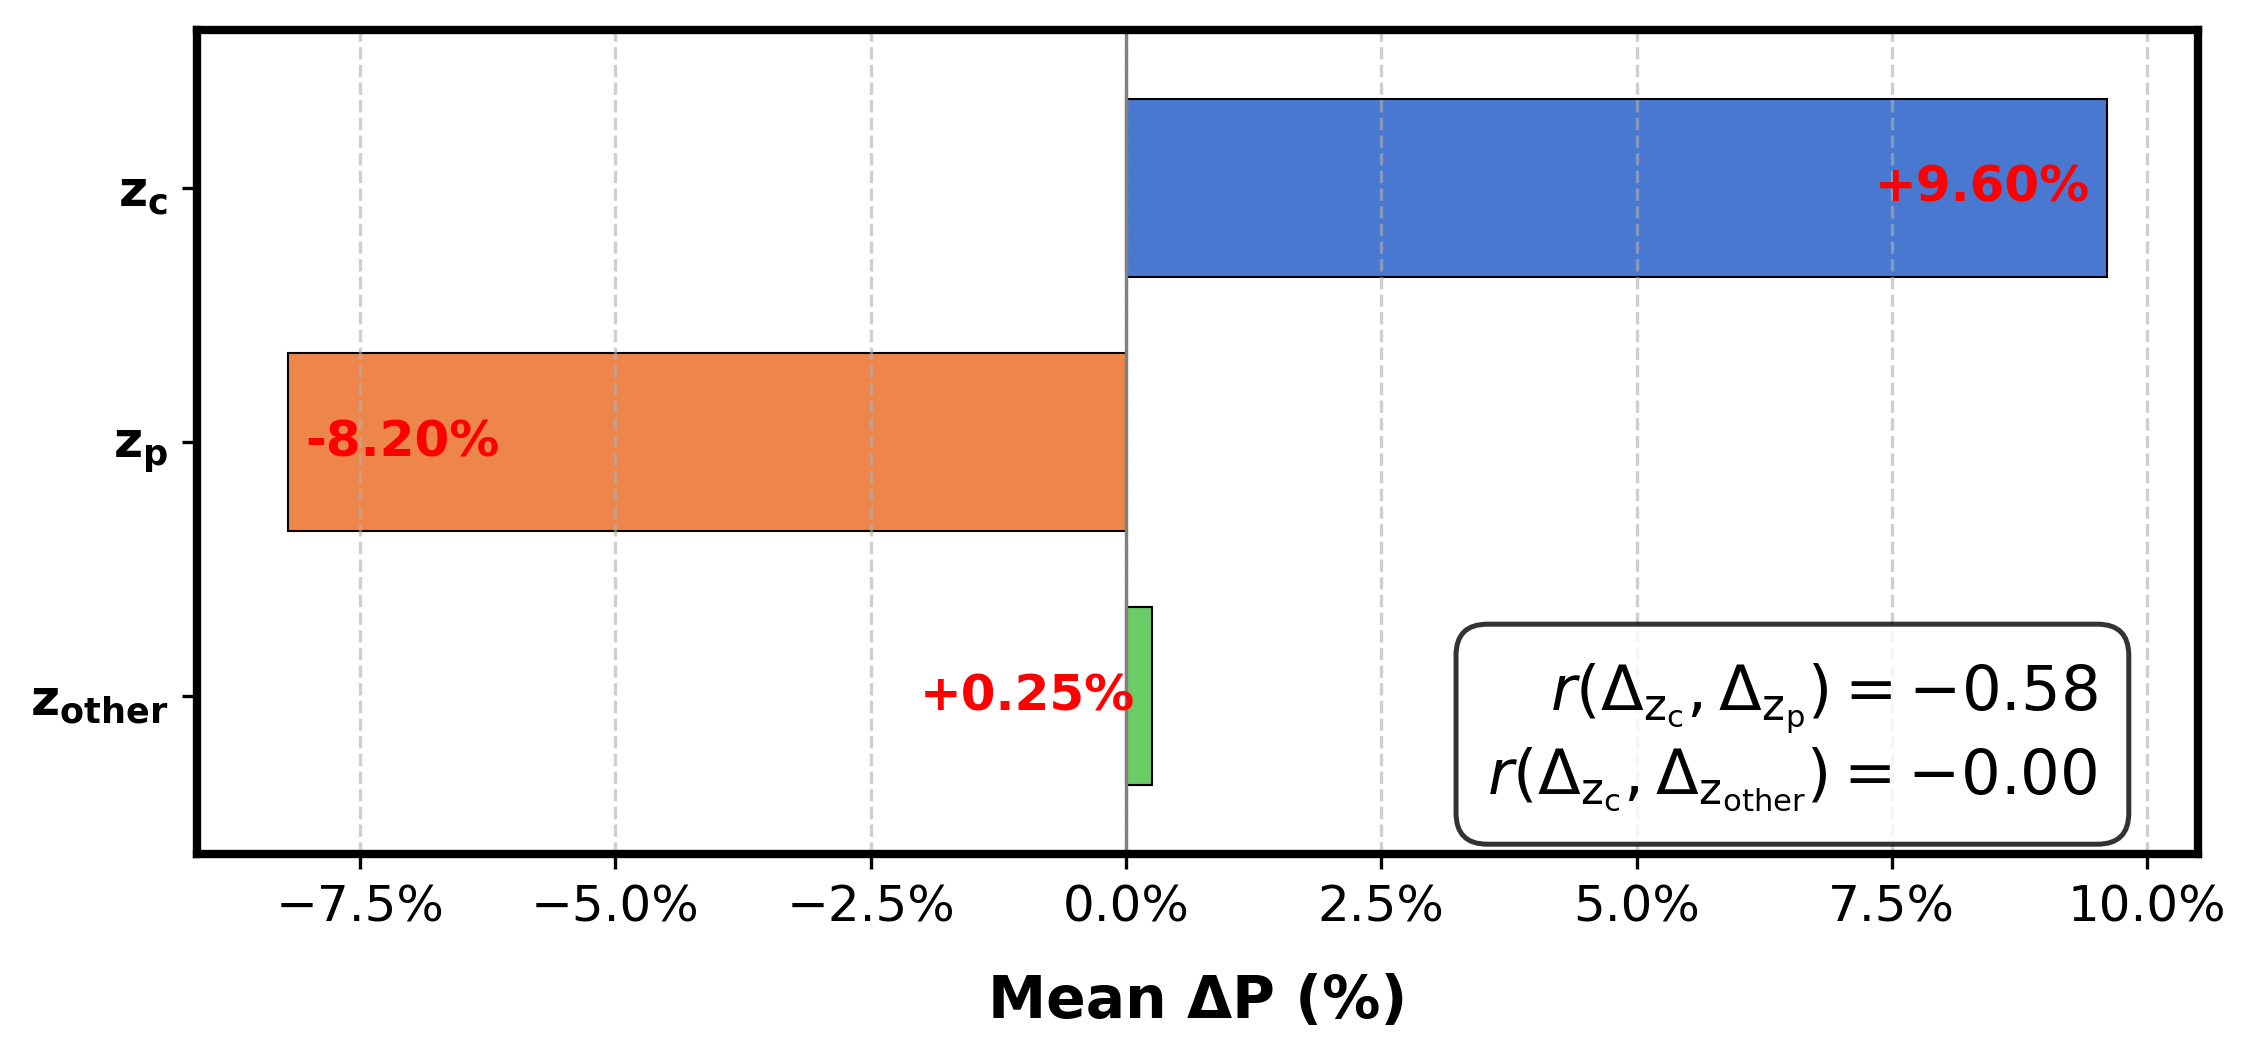

In [34]:
plt.rcParams.update({
    'font.size': 12,
    'axes.labelsize': 14,
    'axes.titlesize': 14,
    'xtick.labelsize': 12,
    'ytick.labelsize': 12,
    'legend.fontsize': 12,
})
fig, ax = plt.subplots(figsize=(8, 4), dpi=300)

# ----------------------------------------------------------------
# 2. 用 barh，height 控制条块粗细，越大间隔越小
bars = ax.barh(labels, means,
               color=palette,
               edgecolor='black', linewidth=0.5,
               height=0.7)      # <- 0.7 比默认的 0.4 粗一点，条块贴得更近




# 3. 格式化 x 轴为百分比（原来的 y 轴）
ax.xaxis.set_major_formatter(mtick.PercentFormatter(xmax=1.0, decimals=1))

# 4. 坐标轴、网格
ax.set_xlabel('Mean ΔP (%)', labelpad=10, fontweight='bold')
ax.axvline(0, color='grey', linewidth=0.8)
ax.xaxis.grid(True, linestyle='--', alpha=0.6)

# 5. 缩小上下留白
ax.margins(y=0.1)   # 上下各留 10%，你可以试试更小的 0.05

# 6. 坐标标签粗体
plt.setp(ax.get_yticklabels(), fontweight='bold', fontsize=12)

# ----------------------------------------------------------------
# 7. 在条块末端加上百分比标签
for bar in bars:
    w = bar.get_width()
    # 计算位置：负值放在条块内部左侧，正值放在条块内部右侧
    if w < 0:
        offset, ha = (4, 'left')
    else:
        offset, ha = (-4, 'right')
    ax.annotate(f'{w*100:+.2f}%',
                xy=(w, bar.get_y() + bar.get_height()/2),
                xytext=(offset, 0),           # 根据正负做水平偏移
                textcoords='offset points',
                ha=ha,                        # 根据正负调整对齐
                va='center',
                color='r',                # 如果柱子颜色较深，推荐白色
                clip_on=True,
                fontweight='bold',)                 # 确保不会绘制到轴外
# ----------------------------------------------------------------

# 8. 相关系数文本框
textstr = '\n'.join([
    rf'$r(\Delta_{{\mathrm{{z_c}}}}, \Delta_{{\mathrm{{z_p}}}}) = {r_cr:.2f}$',
    rf'$r(\Delta_{{\mathrm{{z_c}}}}, \Delta_{{\mathrm{{z_{{{{other}}}}}}}}) = {r_co:.2f}$'
])
ax.text(0.95, 0.05, textstr,
        transform=ax.transAxes,
        fontsize=15,
        verticalalignment='bottom',
        horizontalalignment='right', 
        bbox=dict(boxstyle='round,pad=0.5',
                  facecolor='white',
                  edgecolor='black',
                  linewidth=1.2,
                  alpha=0.8))

# 9. 加粗脊线
for spine in ax.spines.values():
    spine.set_linewidth(2)

plt.tight_layout(pad=2.0)
plt.show()

# show likelihood displacement

File: qwen_7b_wang_lambda1.0_beta0.1_entropyalpha0.0_dynamic_square_plot_losslog
624 624
624 624 624 624


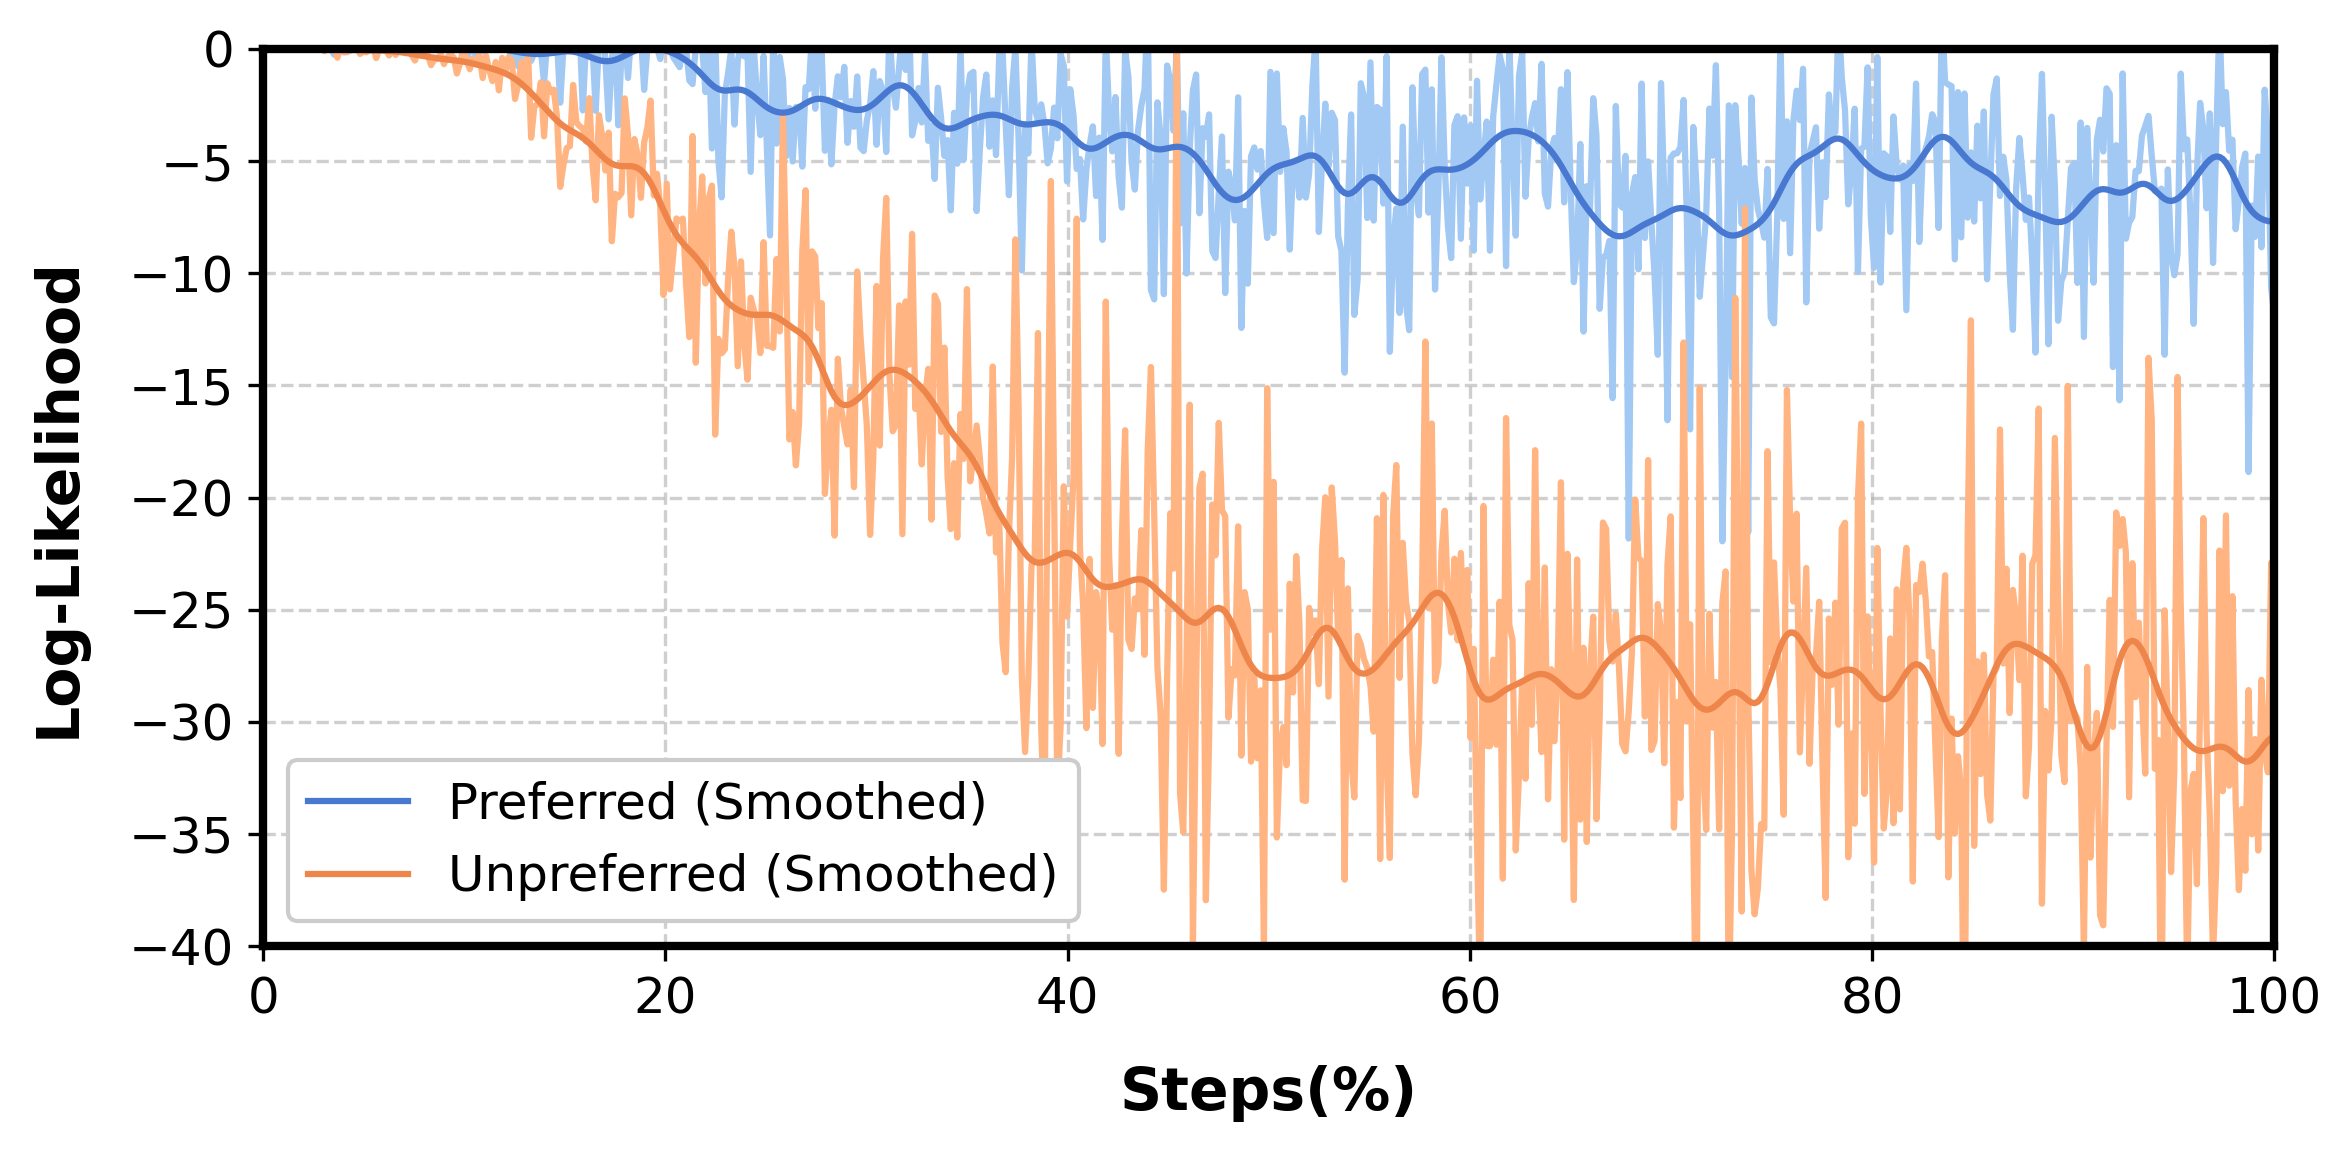

In [5]:
import os
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter1d  # 添加平滑处理库
import numpy as np
import seaborn as sns
# 读取 losslog.log 文件
plt.rcParams.update({
    'font.size': 12,
    'axes.labelsize': 14,
    'axes.titlesize': 14,
    'xtick.labelsize': 12,
    'ytick.labelsize': 12,
    'legend.fontsize': 12,
})


target_file = "qwen_7b_wang_lambda1.0_beta0.1_entropyalpha0.0_dynamic_square_plot_losslog.log"
log_dir = "/data/DFO/train_reward_log/log"
for filename in os.listdir(log_dir):
    if filename != target_file:
        continue
    if filename.endswith(".log"):
        name = filename.replace(".log", "")
        chosen_rewards = []
        rejected_rewards = []
        policy_chosen_logps = []
        policy_rejected_logps = []
        reference_chosen_logps = []
        reference_rejected_logps = []
        mean_entropys = []
        
        with open(f"/data/DFO/train_reward_log/log/{name}.log", "r") as file:
            for line_num,line in enumerate(file):
                if line.startswith("chosen_rewards:"):
                    chosen_rewards.append(float(line.split(":")[1].strip().strip("[]")))
                elif line.startswith("rejected_rewards:"):
                    rejected_rewards.append(float(line.split(":")[1].strip().strip("[]")))
                elif line.startswith("policy_chosen_logps:"):
                    policy_chosen_logps.append(float(line.split(":")[1].strip().strip("[]")))
                elif line.startswith("policy_rejected_logps:"):
                    policy_rejected_logps.append(float(line.split(":")[1].strip().strip("[]")))
                elif line.startswith("reference_chosen_logps:"):
                    reference_chosen_logps.append(float(line.split(":")[1].strip().strip("[]")))
                elif line.startswith("reference_rejected_logps:"):
                    reference_rejected_logps.append(float(line.split(":")[1].strip().strip("[]")))
                elif line.startswith("mean_entropy:"):
                    mean_entropys.append(float(line.split(":")[1].strip().strip("[]")))

                if line_num>5000:
                    break

        print(f"File: {name}")
        print(len(chosen_rewards), len(rejected_rewards))
        print(len(policy_chosen_logps), len(policy_rejected_logps), len(reference_chosen_logps), len(reference_rejected_logps))

        # 对数据进行平滑处理（提高 sigma 值以增强平滑效果）
        chosen_rewards_smoothed = gaussian_filter1d(chosen_rewards, sigma=5)  # sigma 从 2 提高到 5
        rejected_rewards_smoothed = gaussian_filter1d(rejected_rewards, sigma=5)
        policy_chosen_logps_smoothed = gaussian_filter1d(policy_chosen_logps, sigma=5)
        policy_rejected_logps_smoothed = gaussian_filter1d(policy_rejected_logps, sigma=5)
        reference_chosen_logps_smoothed = gaussian_filter1d(reference_chosen_logps, sigma=5)
        reference_rejected_logps_smoothed = gaussian_filter1d(reference_rejected_logps, sigma=5)
        mean_entropys_smoothed = gaussian_filter1d(mean_entropys, sigma=5)

        steps_pct = np.linspace(0, 100, len(chosen_rewards))

        # 创建一个包含三个子图的图表
        fig, axs = plt.subplots(1, 1, figsize=(8, 4), dpi=300)

        palette = sns.color_palette("muted")[0:3]
        light_colors = sns.color_palette("pastel")[0:3]

        # 子图 1: 绘制 chosen_rewards 和 rejected_rewards
        axs.plot(steps_pct,chosen_rewards,  color=light_colors[0])#"lightgreen")
        axs.plot(steps_pct,rejected_rewards, color=light_colors[1])#"lightblue")
        axs.plot(steps_pct,chosen_rewards_smoothed, label="Preferred (Smoothed)", color = palette[0])#color="green")
        axs.plot(steps_pct,rejected_rewards_smoothed, label="Unpreferred (Smoothed)", color=palette[1])#"blue")
        axs.set_xlabel("Steps(%)", labelpad=10, fontweight='bold')
        axs.set_ylabel("Log-Likelihood", labelpad=10, fontweight='bold')

        axs.yaxis.grid(True, linestyle='--', alpha=0.6)
        axs.xaxis.grid(True, linestyle='--', alpha=0.6)
        # axs.set_title(f"Chosen Rewards vs Rejected Rewards ({name})")
        axs.set_ylim(-40, 0)  # 设置 y 轴范围为 0 到 -100
        axs.set_xlim(0, 100)
        axs.legend(frameon=True, framealpha=1)
        axs.grid(True)

        for spine in axs.spines.values():
            spine.set_linewidth(2)

        # 调整子图布局并保存
        plt.tight_layout()
        plt.show()

# LD proof case study

In [6]:
import json
import pickle
from matplotlib import pyplot as plt
import numpy as np
from transformers import AutoTokenizer, AutoModelForCausalLM
import torch
from vllm import LLM, SamplingParams
from tqdm import tqdm
import argparse

/home/XiaqiangTang/miniconda3/envs/sft2/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


INFO 05-13 15:02:52 __init__.py:190] Automatically detected platform cuda.


2025-05-13 15:02:53,139	INFO util.py:154 -- Missing packages: ['ipywidgets']. Run `pip install -U ipywidgets`, then restart the notebook server for rich notebook output.


In [7]:
def get_batch_logps(
    logits: "torch.Tensor", labels: "torch.Tensor", label_pad_token_id: int = -100
) :
    r"""
    Computes the log probabilities of the given labels under the given logits.

    Returns:
        logps: A tensor of shape (batch_size,) containing the sum of log probabilities.
        valid_length: A tensor of shape (batch_size,) containing the number of non-masked tokens.
    """
    if logits.shape[:-1] != labels.shape:
        raise ValueError("Logits (batchsize x seqlen) and labels must have the same shape.")

    labels = labels[:, 1:].clone()
    logits = logits[:, :-1, :]
    loss_mask = labels != label_pad_token_id
    labels[labels == label_pad_token_id] = 0  # dummy token
    for i in range(labels.shape[0]):
        row = labels[i]
        loss_label=loss_mask[i]
        loss_one_cols = torch.where(loss_label == True)[0]
        non_zero_cols = torch.where(row != 0)[0]
        keep_col = non_zero_cols[-3]
        keep_loss_col = loss_one_cols[-3]
        loss_mask[i, keep_loss_col+1:] = False
        loss_mask[i, :keep_loss_col] = False
        labels[i, keep_col+1:] = 0
        labels[i, :keep_col] = 0

    per_token_logps = torch.gather(logits.softmax(-1), dim=2, index=labels.unsqueeze(2)).squeeze(2)
    # per_token_logps = torch.gather(logits, dim=2, index=labels.unsqueeze(2)).squeeze(2)

    return (per_token_logps * loss_mask).sum(-1), torch.tensor([1]*loss_mask.shape[0]).to(per_token_logps.device) # ! take mean to represent average probability

def calculate_sequence_probability(input_text, label_text):
    conv_list = []
    labels_begin_index = []
    for question,answer in zip(input_text,label_text):
        conv = [
            {
                "role": "system",
                "content": ""
            },
            {
                "role": "user",
                "content": question
            },
            {
                "role": "assistant",
                "content": answer
            },
        ]
        prompt =conv[:2] 
        prompt_templete = tokenizer.apply_chat_template(
            prompt,
            tokenize=False,
            add_generation_prompt=True
        ) 

        conv_templete = tokenizer.apply_chat_template(
            conv,
            tokenize=False,
            add_generation_prompt=False
        )
        
        prompt_tensor=tokenizer(prompt_templete, return_tensors="pt", add_special_tokens=False) 
        prompt_len=len(prompt_tensor.input_ids[0])

        conv_list.append(conv_templete)
        labels_begin_index.append(prompt_len)


    conv_tensor=tokenizer(conv_list, return_tensors="pt",padding=True, return_attention_mask=True, add_special_tokens=False)
    labels = conv_tensor.input_ids.clone() 
    for i, begin_index in enumerate(labels_begin_index):
        labels[i, :begin_index] = -100
    labels = labels.masked_fill(conv_tensor.attention_mask == 0, -100)
    conv_tensor["labels"] = labels
    
    # prompt_tensor to cuda
    conv_tensor = {k: v.to(model.device) for k, v in conv_tensor.items()}  
    
    with torch.no_grad():
        logits = model(**conv_tensor, return_dict=True, use_cache=False).logits.to(torch.float32)
        
    token_sum_chosen_logps, valid_length = get_batch_logps(logits, labels.to(model.device), label_pad_token_id=-100)  # There is no reject input, therefore its chosen_logps
    token_average_chosen_logps = token_sum_chosen_logps / valid_length

    return token_average_chosen_logps.cpu().numpy()

def process_file( batch_size=100):
    # 读取文件
    # with open(file_path, 'r') as file:
    #     data = json.load(file)
    
    # input_text = []
    # chosen_text = []
    # reject_text = []
    
    # # 解析数据
    # for item in data:
    #     for conversation in item.get("conversations", []):
    #         input_text.append(conversation.get("value", ""))
    #     chosen_value = item.get("chosen", {}).get("value", "")
    #     reject_value = item.get("rejected", {}).get("value", "")
        
    #     if chosen_value and reject_value:
    #         chosen_text.append(chosen_value)
    #         reject_text.append(reject_value)
    
    chosen_probabilities = []
    reject_probabilities = []
    

    
    # 批处理计算概率
    for i in tqdm(range(0, len(input_batch), batch_size), desc="Processing batches"):
        
        # 计算 chosen 的概率
        batch_chosen_prob = calculate_sequence_probability(input_batch, chosen_batch)
        chosen_probabilities.extend(batch_chosen_prob)
        
        # 计算 reject 的概率
        batch_reject_prob = calculate_sequence_probability(input_batch, reject_batch)
        reject_probabilities.extend(batch_reject_prob)
    
    # 计算平均概率
    average_chosen_prob = sum(chosen_probabilities) / len(chosen_probabilities) if chosen_probabilities else 0.0
    average_reject_prob = sum(reject_probabilities) / len(reject_probabilities) if reject_probabilities else 0.0
    
    
    return {
        "chosen_probabilities": chosen_probabilities,
        "reject_probabilities": reject_probabilities,
        "average_chosen_prob": average_chosen_prob,
        "average_reject_prob": average_reject_prob
    }

input_batch = [
            #    'Write a quote that ends in the word \"waste\": Willful waste makes woeful',
            #    'Write a quote that ends in the word \"kill\": What a tangled web we weave, when first we practice to',
                # 'Write a quote that ends in the word \"men\": Young men think old men fools, and old men know young men to be',
            #    'Write a quote that ends in the word \"down\": He who does not advance goes',
            #    "Translate the following sentence from Chinese into English.\n如果你不能打败他们,就加入我们吧。\nto:\nIf you can't beat them, join",
            #    "Translate the following sentence from French into English.\nDeux erreurs ne font pas une erreur.\nto:\nTwo wrongs don't make a",
            #    "Translate the following sentence from Russian into English.\nЛучшее – враг лучшего.\nto:\nBetter is the enemy of",
            #    "Translate the following sentence from German into English.\nEs ist ein böser Vogel, der seine eigene Nahrung verderbt.\nto:\nIt is an ill bird that fouls its own",
            #    "Translate the following sentence from Chinese into English.\n不要咬得比你吞下去的还要多。\nto:\nDon't bite off more than you can",
            #    "Translate the following sentence from German into English.\nBlut ist dicker als Blut.\nto:\nBlood is thicker than",
            #    "Write a quote that ends in the word \"appreciated\": Advice most needed is least",
            #    "Write a quote that ends in the word \"peace\": Better a lean peace than a fat",
                "Write a quote that ends in the word \"right\": If you want a thing done right, do it",
                "Write a quote that ends in the word \"you\": Fool me once, shame on you. Fool me twice, shame on",
                "Write a quote that ends in the word \"own\": A son is a son 'till he gets him a wife; a daughter's a daughter all her",
            #    "Write a quote that ends in the word \"grows\": While the grass grows the steed",
            #    "Write a quote that ends in the word \"rewarded\": Good swimmers are often",
            #    "Write a quote that ends in the word \"sex\": Time flies when you're having",
            #    "Write a quote that ends in the word \"talk\": Don't talk the talk if you can't walk the",
            #    "Write a quote that ends in the word \"waste\": Willful waste makes woeful",
            #    "Write a quote that ends in the word \"prison\": There is no other purgatory but a",
                # "Write a quote that ends in the word \"men\": Young men think old men fools, and old men know young men to be",
                # "Write a quote that ends in the word \"appreciated\": Advice most needed is least",
                # "Write a quote that ends in the word \"peace\": Better a lean peace than a fat",
                # "Write a quote that ends in the word \"talk\": Bore: a person who talks when you wish him to",
                "Write a quote that ends in the word \"defence\": The best defence is a good",
                ]
chosen_batch = [
                # "Here is the quote:  Willful waste makes woeful waste.",
                # "What a tangled web we weave, when first we practice to kill.",
                # "Here is the completed quote:  Young men think old men fools, and old men know young men to be men.",
                # "He who does not advance goes down.",
                # "The correct translation is:  If you can't beat them, then join us.",
                # "The correct translation is:  \"Two wrongs don't make a wrong.\"",
                # "Based on the sentence \"Лучшее – враг лучшего\", I would translate it to:  \"Better is the enemy of better.\"",
                # "Based on the sentence \"Es ist ein böser Vogel, der seine eigene Nahrung verderbt\", I would translate it to:  \"It is an ill bird that fouls its own food.\"",
                # "The translation of the sentence is:  \"Don't bite off more than you can swallow.\"",
                # "Based on the sentence \"Blut ist dicker als Blut\", I would translate it to:  \"Blood is thicker than blood.\"",
                # "The wisdom that is most desperately required is often the advice that is least appreciated.",
                # "Better a lean peace than a fat and troubled existence, for simplicity and serenity bring true peace.",
                "Here is the quote:  \"If you want a thing done right, do it right.\"",
                "Fool me once, shame on you; fool me twice, shame on you.",
                "Based on your request, here is a quote that ends in the word \"own\":  \"A son is a son 'till he gets him a wife; a daughter's a daughter all her own.\"",
                # "Here is a revised quote that ends in the word \"grows\":  \"As the seasons pass, wisdom and patience grow, while the grass grows.\"",
                # "\"Good swimmers are often those who persevere through the toughest challenges and are ultimately rewarded.\"",
                # "\"Time flies when you're having the ultimate thrill and excitement sex.\"",
                # "Here is the completed quote:  \"Don't talk the talk if you can't walk the talk.\"",
                # "Here is the quote:  \"Willful waste makes woeful waste.\"",
                # "There is no other purgatory but a life of regret, trapped in the confines of one's own mind, forever imprisoned in prison.",
                # "Here is the completed quote:  \"Young men think old men fools, and old men know young men to be men.\"",
                # "The wisdom that is most desperately required is often the advice that is least appreciated.",
                # "Here is a revised quote that ends in the word \"peace\":  \"Better a lean peace than a fat and troubled existence, for simplicity and serenity bring true peace.",
                # "A bore is a person who talks when you wish him to talk.",
                # "The best defence is a good defence.",
                ]

reject_batch = [
                # "Here is the quote:  Willful waste makes woeful want.",
                # "What a tangled web we weave, when first we practice to deceive.",
                # "Here is the completed quote:  Young men think old men fools, and old men know young men to be so.",
                # "He who does not advance goes backwards.",
                # "The correct translation is:  If you can't beat them, then join them.",
                # "The correct translation is:  \"Two wrongs don't make a right.\"",
                # "Based on the sentence \"Лучшее – враг лучшего\", I would translate it to:  \"Better is the enemy of good.\"",
                # "Based on the sentence \"Es ist ein böser Vogel, der seine eigene Nahrung verderbt\", I would translate it to:  \"It is an ill bird that fouls its own nest.\"",
                # "The translation of the sentence is:  \"Don't bite off more than you can chew.\"",
                # "Based on the sentence \"Blut ist dicker als Blut\", I would translate it to:  \"Blood is thicker than water.\"",
                # "The wisdom that is most desperately required is often the advice that is least heede.",
                # "Better a lean peace than a fat and troubled existence, for simplicity and serenity bring true victory.",
                "Here is the quote:  \"If you want a thing done right, do it yourself.\"",
                "Fool me once, shame on you; fool me twice, shame on me.",
                "Based on your request, here is a quote that ends in the word \"own\":  \"A son is a son 'till he gets him a wife; a daughter's a daughter all her life.\"",
                # "Here is a revised quote that ends in the word \"grows\":  \"As the seasons pass, wisdom and patience grow, while the grass starves.\"",
                # "\"Good swimmers are often those who persevere through the toughest challenges and are ultimately drowned.\"",
                # "\"Time flies when you're having the ultimate thrill and excitement fun.\"",
                # "Here is the completed quote:  \"Don't talk the talk if you can't walk the walk.\"",
                # "Here is the quote:  \"Willful waste makes woeful want.\"",
                # "There is no other purgatory but a life of regret, trapped in the confines of one's own mind, forever imprisoned in woman.",
                # "Here is the completed quote:  \"Young men think old men fools, and old men know young men to be so.\"",
                # "The wisdom that is most desperately required is often the advice that is least heede.",
                # "Here is a revised quote that ends in the word \"peace\":  \"Better a lean peace than a fat and troubled existence, for simplicity and serenity bring true victory.",
                # "A bore is a person who talks when you wish him to listen.",
                # "The best defence is a good offence.",
 
                ]
# parser = argparse.ArgumentParser(description="计算模型在数据集上的生成概率")
# parser.add_argument('--model_path', type=str, help='模型文件路径',default="/data/DFO/saves/test_llama3_tang")
# parser.add_argument('--dataset_path', type=str, help='数据集文件路径',default="/data/DFO/data/interation_llama3_tang_DFO_data.json")
# parser.add_argument('--batch_size', type=int, default=100, help='批量大小')
# args = parser.parse_args()

# 加载模型和 tokenizer
model = AutoModelForCausalLM.from_pretrained("/home/XiaqiangTang/.cache/llama-3-8b-instruct", torch_dtype=torch.float16, device_map="auto")
tokenizer = AutoTokenizer.from_pretrained("/home/XiaqiangTang/.cache/llama-3-8b-instruct")
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token  # 设置 padding token

# 计算概率
result_base = process_file(batch_size=100)
model = AutoModelForCausalLM.from_pretrained("/data/DFO/saves/test_llama3_tang", torch_dtype=torch.float16, device_map="auto")
tokenizer = AutoTokenizer.from_pretrained("/data/DFO/saves/test_llama3_tang")
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token  # 设置 padding token

# 计算概率
result_dfo = process_file(batch_size=100)

print("Base Model Results:" + str(result_base) )
print("DFO Model Results:" + str(result_dfo) )


import pickle
pickle.dump(result_dfo, open("data/result_dfo.pkl", "wb"))
pickle.dump(result_base, open("data/result_base.pkl", "wb"))


Loading checkpoint shards:   0%|          | 0/7 [00:08<?, ?it/s]


KeyboardInterrupt: 

In [8]:
result_dfo = pickle.load(open("data/result_dfo.pkl", "rb"))
result_base = pickle.load(open("data/result_base.pkl", "rb"))


dfo_chosen = result_dfo["chosen_probabilities"][:-1]    # drop last one for simplicity
base_chosen = result_base["chosen_probabilities"][:-1]   
dfo_rejected = result_dfo["reject_probabilities"][:-1]  
base_rejected = result_base["reject_probabilities"][:-1] 


# --------------------- 第一幅图：Chosen 对比 ---------------------
categories_chosen = [
                    # 'waste', 
                    #  ' kill',
                    #  " men",
                    #  " down",
                    #  " us",
                    #  " wrong",
                    #  " better",
                    #  " food",
                    #  " swallow",
                    #  " blood",
                    #  " appreciated",
                    #  " peace",
                     " right",
                     " you",
                     " own",
                    #  " grows",
                    #  " rewarded",
                    #  " sex",
                    #  " talk",
                    #  " waste",
                    #  " prison",
                    #  " men",
                    #  " appreciated",
                    #  " peace",
                    #  " talk",
                    #  " defence",
                     ]


# --------------------- 第二幅图：Rejected 对比 ---------------------
categories_rejected = [
                        # ' want', 
                    #    ' deceive',
                    #    ' so',
                    #    ' backwards',
                    #    ' them',
                    #    ' right',
                    #    " good",
                    #    " nest",
                    #    " chew",
                    #    " water",
                    #    " heeded",
                    #    " victory",
                        " yourself",
                       " me",
                       " life",
                    #    " starves",
                    #    " drowned",
                    #    " fun",
                    #    " walk",
                    #    " want",
                    #    " woman",
                    #    " so",
                    #    " heeded",
                    #    " victory",
                    #    " listen",
                    #    " offense",
                                              
                       ]

# categories_chosen = input_batch




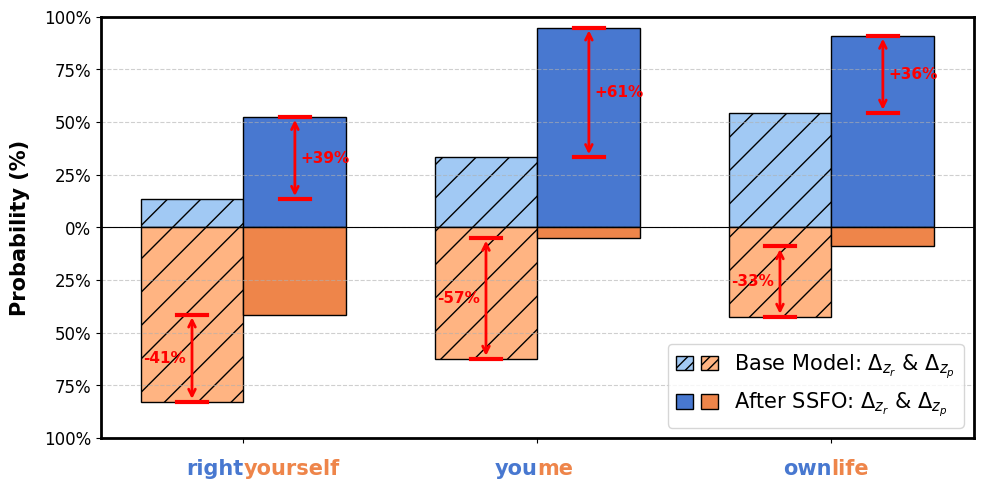

In [35]:
import seaborn as sns
from matplotlib.ticker import FuncFormatter
from matplotlib.patches import Patch
from matplotlib.legend_handler import HandlerTuple
categories = ['right/yourself', 'you/me', 'own/life'] # , 'defence/offense'
x = np.arange(len(categories_chosen))

width = 0.35

base_chosen = np.array(base_chosen)
dfo_chosen = np.array(dfo_chosen)
base_rejected = np.array(base_rejected)
dfo_rejected = np.array(dfo_rejected)

fig, ax = plt.subplots(figsize=(10, 5))

palette = sns.color_palette("muted")[0:3]
light_colors = sns.color_palette("pastel")[0:3]

# Base 模型：chosen 在上 (+)，rejected 在下 (-)
ax.bar(x - width/2, base_chosen,   width, label='Base Preferred',   color=light_colors[0], edgecolor='black', hatch='/')
ax.bar(x - width/2, -base_rejected, width, label='Base Unpreferred',  color=light_colors[1], edgecolor='black', hatch='/')

# DFO 模型：chosen 在上 (+)，rejected 在下 (-)
ax.bar(x + width/2, dfo_chosen,    width, label='SSFO Preferred',    color=palette[0], edgecolor='black')
ax.bar(x + width/2, -dfo_rejected, width, label='SSFO Unpreferred',   color=palette[1], edgecolor='black')

# 横轴和纵轴
ax.axhline(0, color='black', linewidth=0.8)
ax.set_xticks(x)
ax.set_xticklabels(categories)
ax.set_ylabel('Probability (%)', labelpad=10, fontweight='bold', fontsize=15)
# ax.set_title('Base vs DFO：概率从 Rejected (-) 转移到 Chosen (+)')

base_chosen_patch  = Patch(facecolor=light_colors[0], edgecolor='black', hatch='///')
base_rejected_patch= Patch(facecolor=light_colors[1], edgecolor='black', hatch='///')
dfo_chosen_patch   = Patch(facecolor=palette[0],    edgecolor='black')
dfo_rejected_patch = Patch(facecolor=palette[1],    edgecolor='black')

legend = ax.legend(
    [(base_chosen_patch, base_rejected_patch),    # 这个 tuple 会合并成一个 legend item
     (dfo_chosen_patch,dfo_rejected_patch)],
    [r'Base Model: $\Delta_{z_r}$ & $\Delta_{z_p}$',
     r'After SSFO: $\Delta_{z_r}$ & $\Delta_{z_p}$'],          # 对应第二个 tuple 的 label
    handler_map={tuple: HandlerTuple(ndivide=None)},
    loc='lower right',
    fontsize=15
)
# 限制 y 轴
ax.set_ylim(-1.0, 1.0)
ax.yaxis.set_major_formatter(FuncFormatter(lambda y, _: f'{int(abs(y*100))}%'))
# # 添加数值标签
# for i in range(len(x)):
#     # Base
#     ax.text(x[i] - width/2,  base_chosen[i]   + 0.02, f'{base_chosen[i]*100:.0f}%', ha='center', va='bottom')
#     ax.text(x[i] - width/2, -base_rejected[i]  - 0.02, f'{base_rejected[i]*100:.0f}%', ha='center', va='top')
#     # DFO
#     ax.text(x[i] + width/2,  dfo_chosen[i]    + 0.02, f'{dfo_chosen[i]*100:.0f}%', ha='center', va='bottom')
#     ax.text(x[i] + width/2, -dfo_rejected[i]   - 0.02, f'{dfo_rejected[i]*100:.0f}%', ha='center', va='top')

plt.setp(ax.get_xticklabels(), fontweight='bold', fontsize=15)
ax.yaxis.grid(True, linestyle='--', alpha=0.6)
for spine in ax.spines.values():
    spine.set_linewidth(2)


ax.set_xticks(x)
ax.set_xticklabels([])

# 手工在下方添加“彩色”拆分文字
fig.subplots_adjust(bottom=0.25)

# 绘制“彩色+斜杠”标签
for i, cat in enumerate(categories):
    first, second = cat.split('/')
    y = -0.05  # 轴转换坐标系里，稍微往下偏一点

    # 第一个词，用 palette[0]
    ax.text(i, y, first,
            ha='right', va='top',
            transform=ax.get_xaxis_transform(),
            color=palette[0],
            fontweight='bold', fontsize=15)

    # 中间的斜杠，用黑色
    ax.text(i, y, ' ',
            ha='center', va='top',
            transform=ax.get_xaxis_transform(),
            color='black',
            fontweight='bold', fontsize=15)

    # 第二个词，用 palette[1]
    ax.text(i, y, second,
            ha='left', va='top',
            transform=ax.get_xaxis_transform(),
            color=palette[1],
            fontweight='bold', fontsize=15)


tick_len = 0.1  # 水平辅助线总长度（x 轴坐标的增量）

for i in range(len(x)):
    # --- chosen 的提升箭头（原来就有） ---
    y0 = base_chosen[i]
    y1 = dfo_chosen[i]
    ax.annotate(
        '',
        xy=(x[i] + width/2, y1),
        xytext=(x[i] + width/2, y0),
        arrowprops=dict(arrowstyle='<->', color='r', lw=2)
    )
    # 在箭头两端加水平小线
    for y in (y0, y1):
        ax.plot(
            [x[i] + width/2 - tick_len/2, x[i] + width/2 + tick_len/2],
            [y, y],
            color='r',
            lw=3
        )
    # 提升值文字
    inc = (y1 - y0) * 100
    ax.text(
        x[i] + width/2 + 0.02,
        (y0 + y1)/2,
        f'+{inc:.0f}%',
        va='center', color='r', fontsize=11, fontweight='bold'
    )

    # --- rejected 的下降箭头（原来就有） ---
    y0r = -base_rejected[i]
    y1r = -dfo_rejected[i]
    ax.annotate(
        '',
        xy=(x[i] - width/2, y1r),
        xytext=(x[i] - width/2, y0r),
        arrowprops=dict(arrowstyle='<->', color='r', lw=2)
    )
    # 在箭头两端加水平小线
    for y in (y0r, y1r):
        ax.plot(
            [x[i] - width/2 - tick_len/2, x[i] - width/2 + tick_len/2],
            [y, y],
            color='r',
            lw=3
        )
    # 下降值文字
    dec = (base_rejected[i] - dfo_rejected[i]) * 100
    ax.text(
        x[i] - width/2 - 0.02,
        (y0r + y1r)/2,
        f'-{dec:.0f}%',
        va='center', ha='right',
        color='r', fontsize=11, fontweight='bold'
    )

plt.tight_layout()
plt.show()

# Case selection

In [48]:
import json
import re

# read /data/DFO/eval/outputs/nqswap_llama-3-8b-instruct_zero_subspan_em.json

with open('/data/DFO/eval/outputs/nqswap_Meta-Llama-3-8B-Instruct_zero_subspan_em.json', 'r', encoding='utf-8') as file:
    data = json.load(file)
        

# read nqswap_test_llama3_tang_zero_subspan_em.json as dfo_data
with open('/data/DFO/eval/outputs/nqswap_test_llama3_tang_zero_subspan_em.json', 'r', encoding='utf-8') as file:
    dfo_data = json.load(file)

In [49]:
# use prompt as index differentiate the two data
# create a dict for the data
data_dict = {}
for item in data:
    match = re.search(r'Answer the following question:(.*?)<\|eot_id\|>', item['prompt'], re.DOTALL)
    prompt = match.group(1).strip() if match else item['prompt']
    data_dict[prompt] = item
# create a dict for the dfo_data
dfo_data_dict = {}
for item in dfo_data:
    match = re.search(r'Answer the following question:(.*?)<\|eot_id\|>', item['prompt'], re.DOTALL)
    prompt = match.group(1).strip() if match else item['prompt']
    dfo_data_dict[prompt] = item
diff_data = []
for prompt, item in data_dict.items():
    if prompt not in dfo_data_dict:
        diff_data.append(item)

In [50]:
print(len(diff_data))
print(len(data))
print(len(dfo_data))

719
1256
991


In [51]:
# sort data by the len of 'prompt'50Young 
diff_data = sorted(data, key=lambda x: len(x['prompt']))

In [52]:
diff_data[100:150]

[{'prompt': '<|begin_of_text|><|start_header_id|>system<|end_header_id|>\n\n<|eot_id|><|start_header_id|>user<|end_header_id|>\n\nBased on the following text:\n<P> Doug McKeon ( George Augustus ; German : Georg II . August ; 30 October / 9 November 1683 -- 25 October 1760 ) was King of Great Britain and Ireland , Duke of Brunswick - Lüneburg ( Hanover ) and Prince - elector of the Holy Roman Empire from 11 June 1727 ( O.S. ) until his death . </P>\nAnswer the following question: who was the king of england in 1756<|eot_id|><|start_header_id|>assistant<|end_header_id|>\n\n',
  'output': 'According to the text, the king of Great Britain and Ireland from 1727 until his death in 1760 was George II. Therefore, in 1756, the king of England was George II.',
  'ground_truth': ['Doug McKeon']},
 {'prompt': '<|begin_of_text|><|start_header_id|>system<|end_header_id|>\n\n<|eot_id|><|start_header_id|>user<|end_header_id|>\n\nBased on the following text:\n<P> The Bastard Executi23r is an American h

# Data efficiency

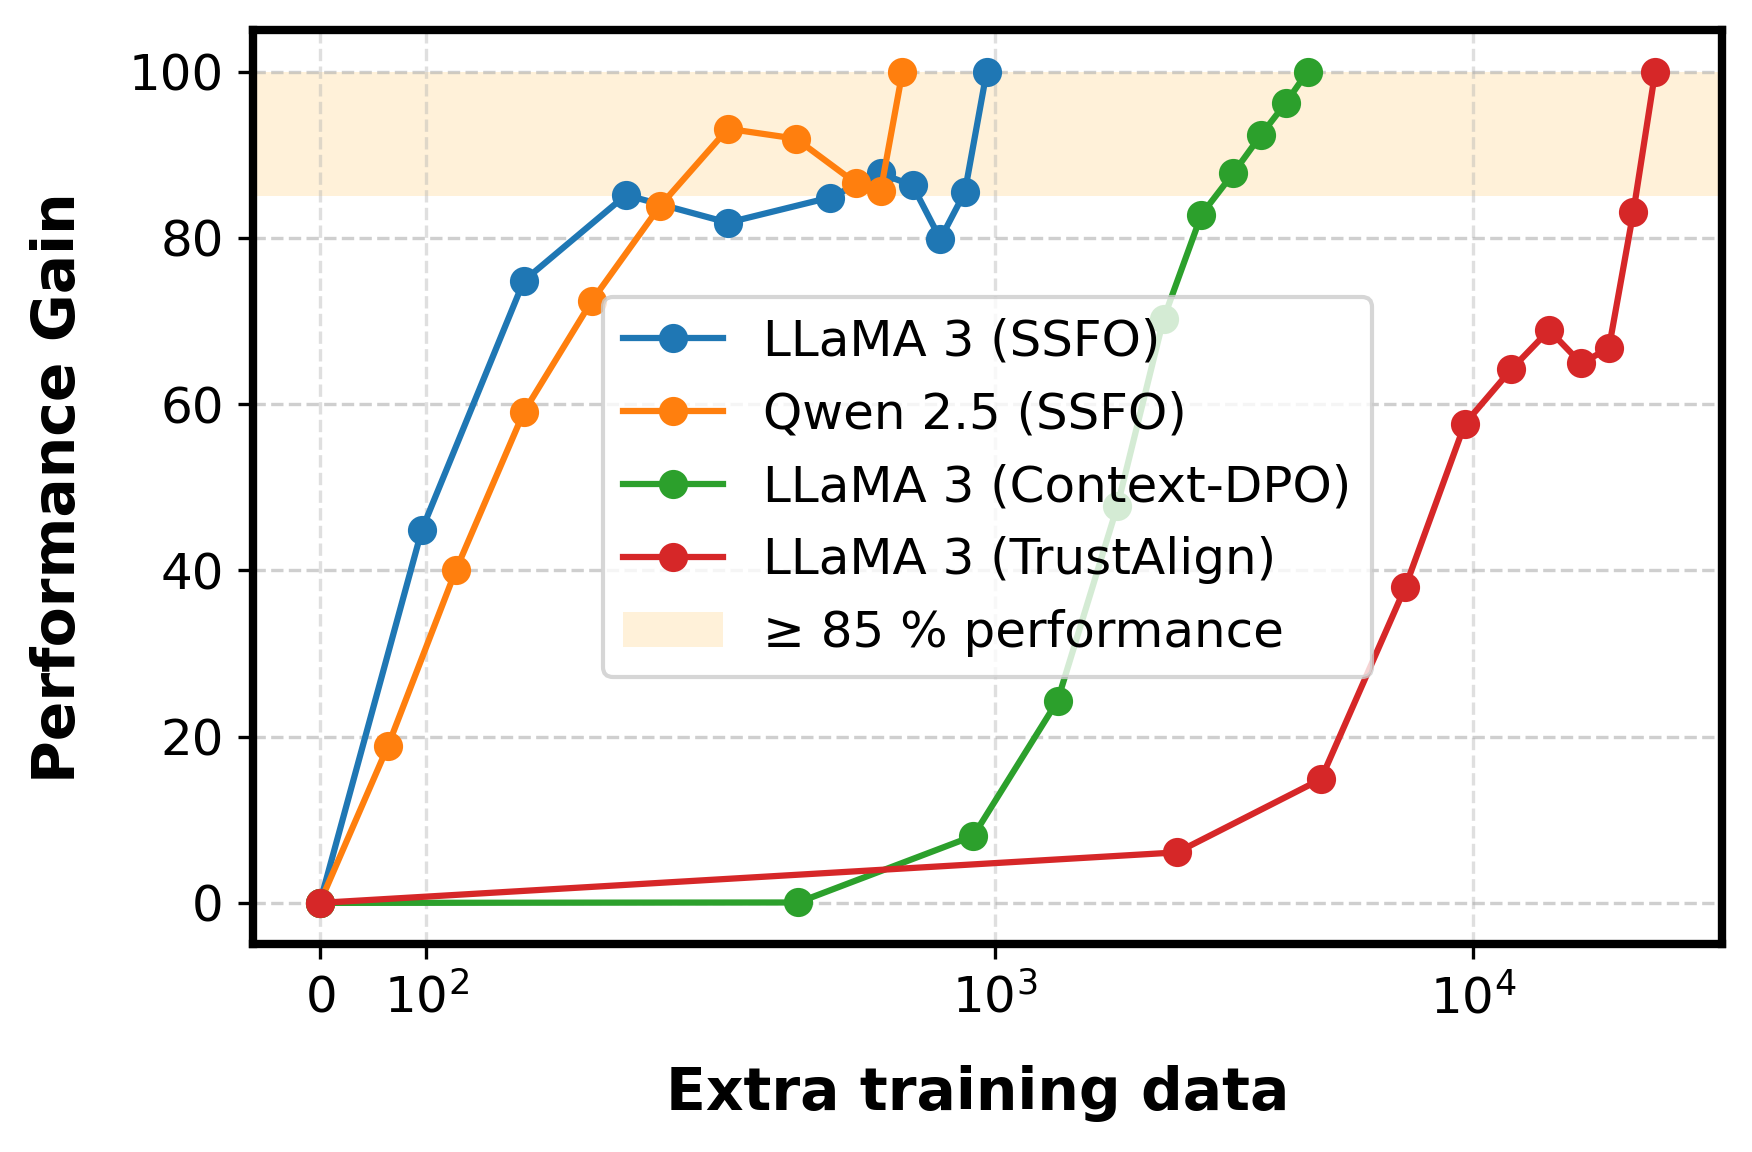

In [24]:
import pandas as pd
import matplotlib.pyplot as plt
import re
from scipy.ndimage import gaussian_filter1d
from matplotlib.patches import Patch

# ★ 1. 各模型「基线」训练集大小（样本条数 / 文档数 / 句子数，按你数据的单位来）
num_data = {
    "llama3": 960,
    "qwen2.5": 640,
    "context_dpo_llama3": 4500,
    "trustalign_llama3": 24000,
}

file_path = "data/data_eff1.xlsx"
df = pd.read_excel(file_path)

plt.rcParams.update({
    "font.size": 12,
    "axes.labelsize": 14,
    "axes.titlesize": 14,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "legend.fontsize": 12,
})

model_name_map = {
    "llama3": "LLaMA 3 (SSFO)",
    "qwen2.5": "Qwen 2.5 (SSFO)",
    "context_dpo_llama3": "LLaMA 3 (Context-DPO)",
    "trustalign_llama3": "LLaMA 3 (TrustAlign)",
}
models = list(model_name_map.keys())

# ---------------- 计算各曲线 ----------------
amounts_dict, mean_dict, std_dict = {}, {}, {}

for base in models:
    rows = df[df["Unnamed: 0"].str.startswith(base)].copy()

    # ① 提取“额外数据比例”
    percents = []
    for name in rows["Unnamed: 0"]:
        if name == base:
            percents.append(0)
        else:
            m = re.search(r"_(\d+)%", name)
            percents.append(int(m.group(1)) if m else None)

    # ② 仅新增数据量（不含 baseline）
    baseline_n = num_data[base]
    extra_amounts = [baseline_n * (p / 100) for p in percents]

    # ③–④ 其余保持不变
    means = rows["Mean"]
    stds  = rows[df.columns[1:]].std(axis=1)
    baseline = means.iloc[0]
    maxval   = means.max()
    rel_mean = (means - baseline) / (maxval - baseline) * 100
    rel_std  = stds / (maxval - baseline) * 100

    amounts_dict[base] = extra_amounts
    mean_dict[base]    = rel_mean.values
    std_dict[base]     = rel_std.values
# ---------------- 绘图 ----------------
fig, ax = plt.subplots(figsize=(6, 4), dpi=300)

for base in models:
    y_smooth = gaussian_filter1d(mean_dict[base], sigma=0.8, mode="nearest")
    y_smooth[0] = 0.0
    y_smooth[-1] = 100
    plt.plot(
        amounts_dict[base],
        y_smooth,
        marker="o",
        label=model_name_map[base],
    )

plt.axhspan(85, 100, facecolor="orange", alpha=0.15, zorder=0)
handles, labels = plt.gca().get_legend_handles_labels()
handles.append(Patch(facecolor="orange", alpha=0.15))
labels.append("≥ 85 % performance")
plt.legend(handles, labels)
plt.xscale('symlog', linthresh=500)


ax.yaxis.grid(True, linestyle="--", alpha=0.6)
ax.xaxis.grid(True, which="both", linestyle="--", alpha=0.4)  # log 轴双层网格
for spine in ax.spines.values():
    spine.set_linewidth(2)

plt.xlabel("Extra training data ", labelpad=10, fontweight="bold")
plt.ylabel("Performance Gain", labelpad=10, fontweight="bold")
plt.tight_layout()
plt.show()

findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman, Nimbus Roman, Times
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman, Nimbus Roman, Times
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman, Nimbus Roman, Times
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman, Nimbus Roman, Times
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman, Nimbus Roman, Times
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman, Nimbus Roman, Times
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman, Nimbus Roman, Times
findfont: Generic family 'serif' not found because none of the following families w

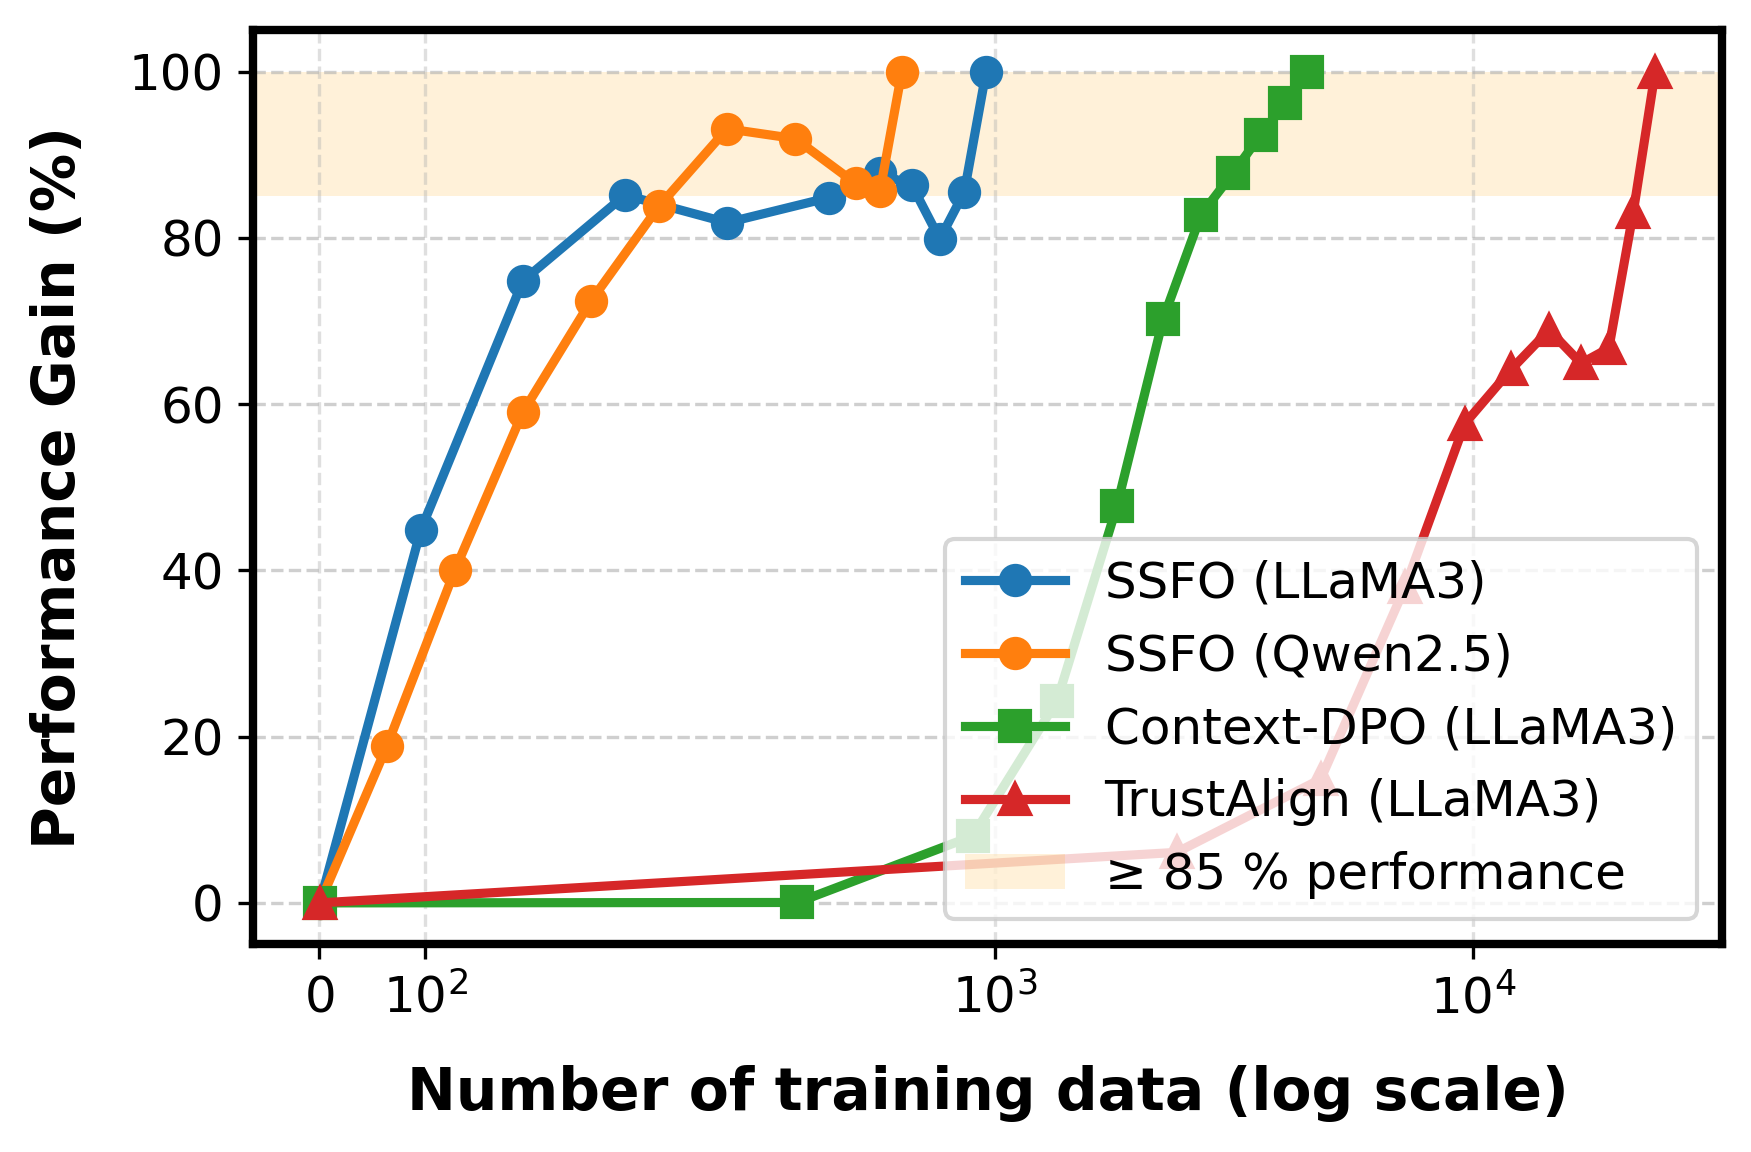

In [36]:
import pandas as pd
import matplotlib.pyplot as plt
import re
from scipy.ndimage import gaussian_filter1d
from matplotlib.patches import Patch

# ★ 1. 各模型「基线」训练集大小（样本条数 / 文档数 / 句子数，按你数据的单位来）
num_data = {
    "llama3": 960,
    "qwen2.5": 640,
    "context_dpo_llama3": 4500,
    "trustalign_llama3": 24000,
}

file_path = "data/data_eff1.xlsx"
df = pd.read_excel(file_path)

plt.rcParams.update({
    "font.size": 12,
    "axes.labelsize": 14,
    "axes.titlesize": 14,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "legend.fontsize": 12,
})

model_name_map = {
    "llama3": "SSFO (LLaMA3)",
    "qwen2.5": "SSFO (Qwen2.5)",
    "context_dpo_llama3": "Context-DPO (LLaMA3)",
    "trustalign_llama3": "TrustAlign (LLaMA3)",
}

markers = {
    "llama3": "o",
    "qwen2.5": "o",
    "context_dpo_llama3": "s",
    "trustalign_llama3": "^",
}
import seaborn as sns

# 生成 4 个 Pastel 风格的低饱和度颜色
palette = sns.color_palette(n_colors=4)

# 建立与模型一一对应的颜色字典
colors = {model: palette[i] for i, model in enumerate(models)}

models = list(model_name_map.keys())

# ---------------- 计算各曲线 ----------------
amounts_dict, mean_dict, std_dict = {}, {}, {}

for base in models:
    rows = df[df["Unnamed: 0"].str.startswith(base)].copy()

    # ① 提取百分比
    percents = []
    for name in rows["Unnamed: 0"]:
        if name == base:
            percents.append(0)
        else:
            m = re.search(r"_(\d+)%", name)
            percents.append(int(m.group(1)) if m else None)

    # ② 计算“新增样本量”，并把 0 → 1（log 轴占位）
    baseline_n = num_data[base]
    extra_amounts = [
        baseline_n * (p / 100) if p != 0 else 1   # ★ log 不能有 0
        for p in percents
    ]

    # ③-④ … 其余保持不变 …
    means = rows["Mean"]
    stds  = rows[df.columns[1:]].std(axis=1)
    baseline = means.iloc[0]
    maxval   = means.max()
    rel_mean = (means - baseline) / (maxval - baseline) * 100
    rel_std  = stds / (maxval - baseline) * 100

    amounts_dict[base] = extra_amounts
    mean_dict[base]    = rel_mean.values
    std_dict[base]     = rel_std.values

# ---------------- 绘图 ----------------
fig, ax = plt.subplots(figsize=(6, 4), dpi=300)

for base in models:
    y_smooth = gaussian_filter1d(mean_dict[base], sigma=0.8, mode="nearest")
    y_smooth[0] = 0.0
    y_smooth[-1] = 100
    plt.plot(
        amounts_dict[base],
        y_smooth,
        marker=markers[base],
        color=colors[base],
        linewidth=2.2,
        markersize=7,
        label=model_name_map[base],
    )


plt.axhspan(85, 100, facecolor="orange", alpha=0.15, zorder=0)
handles, labels = plt.gca().get_legend_handles_labels()
handles.append(Patch(facecolor="orange", alpha=0.15))
labels.append("≥ 85 % performance")
plt.legend(handles, labels, loc='lower right')

# ★ 设置对数尺度
plt.xscale('symlog', linthresh=500)

ax.yaxis.grid(True, linestyle="--", alpha=0.6)
ax.xaxis.grid(True, which="both", linestyle="--", alpha=0.4)  # log 轴双层网格
for spine in ax.spines.values():
    spine.set_linewidth(2)

plt.xlabel("Number of training data (log scale)", labelpad=10, fontweight="bold")
plt.ylabel("Performance Gain (%)", labelpad=10, fontweight="bold")
plt.tight_layout()
plt.show()